In [13]:
#!pip install arch

In [14]:
#!pip install rpy2

In [ ]:
#!pip install pydynpd

In [168]:
#import subprocess
#import sys

#print("="*70)
#print("УСТАНОВКА ПАКЕТА linearmodels")
#print("="*70)

#try:
    #subprocess.check_call([sys.executable, "-m", "pip", "install", "linearmodels", "-q"])
    #print("✓ Пакет linearmodels успешно установлен")
#except Exception as e:
   # print(f"✗ Ошибка при установке: {e}")

# Проверка импорта
#try:
   # from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
    #print("✓ Импорт linearmodels успешен")
#except ImportError as e:
    #print(f"✗ Ошибка импорта: {e}")

УСТАНОВКА ПАКЕТА linearmodels
✓ Пакет linearmodels успешно установлен
✓ Импорт linearmodels успешен


In [195]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import arch.unitroot as au
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import friedmanchisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.tsa.ardl import ARDL, ardl_select_order
import sys
import os
os.environ['RPY2_CFFI_MODE'] = 'ABI'
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
import itertools
import math
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from scipy.stats import chi2, f
from statsmodels.tsa.x13 import x13_arima_analysis
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, globalenv
from rpy2.robjects.packages import importr, isinstalled
from rpy2.robjects.conversion import localconverter
import rpy2.rinterface_lib.callbacks
import os

In [196]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data')
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
households_structure = pd.read_excel('База_соц эконом неоднор регионов.xlsx', skiprows=1, sheet_name = 'Фин пол ДХ')
households_loans = pd.read_excel('База_соц эконом неоднор регионов.xlsx', sheet_name = 'КЖН (рейтинг)')
funds_coefficient = pd.read_excel('База_соц эконом неоднор регионов.xlsx', skiprows=2, sheet_name = 'Коэф фондов')

In [197]:
# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])

In [198]:
df_reg.head()

,Num_reg,Region,Date,D_top5_rozn,Cred_nagr,Zakred,Zadolg_Fl,Zadolg_Mort,Zadolg_ConsCred,Zadolg_Fl_mom,...,New_Loans_Progr_DOMRF_mom,New_Loans_Progr_mom,Int_Rate_FL,Int_Rate_Mort,Int_Rate_ConsCred,Int_Rate_Progr_DOMRF,Int_Rate_Progr,Fin_Dostup,LTV_proksi,Credit_impulse
0,1,Белгородская область,2019-02-01,0.720458,0.327789,45.661946,1.252168e+08,43448108.04,81768732.08,1.008396,...,NaN,NaN,13.637133,9.822596,14.919927,5.714816,NaN,24.878034,0.727030,-2.177079
1,1,Белгородская область,2019-03-01,0.721863,0.332653,46.108548,1.268473e+08,44177731.36,82669591.94,1.302566,...,-50.982514,NaN,13.764491,10.119091,15.090566,5.688207,NaN,25.004848,0.674074,0.715653
2,1,Белгородская область,2019-04-01,0.724760,0.336535,46.483680,1.288264e+08,44889934.26,83936427.82,1.561441,...,-65.329715,NaN,13.988365,10.431156,15.022465,5.503984,NaN,24.937820,0.347733,1.734442
3,1,Белгородская область,2019-05-01,0.724868,0.341271,47.069180,1.315857e+08,45651657.65,85934076.07,2.141982,...,220.452622,NaN,13.975779,10.629171,14.943737,5.496568,NaN,24.870805,0.677991,2.897391
4,1,Белгородская область,2019-06-01,0.724590,0.342186,47.580388,1.339479e+08,46227839.22,87720098.33,1.794755,...,40.154704,NaN,14.197338,10.697008,15.138499,5.278560,NaN,24.803802,0.655120,2.214858


In [199]:
df_RF.head()

,Num_reg,Region,Date,CAR_Indicator,D_Progr_mort,ROISFIX,exc_rate,exc_rate_diff,Bonds_Rate_Correct_5Y,Inflation_Expectations,Nominal_Percent_Rate,Ent_conf_ind_mining,Ent_conf_ind_manufactoring,Covid_dum,Sank_dum
0,0,РОССИЯ,2019-02-01,0.146150,0.013333,7.652000,65.810525,-0.702019,0.274500,10.362319,6.5,0,-2,0,0
1,0,РОССИЯ,2019-03-01,0.146823,0.014805,7.611500,65.092257,-0.718268,0.292500,10.144295,6.5,1,-2,0,0
2,0,РОССИЯ,2019-04-01,0.146778,0.017586,7.630000,64.603105,-0.489152,0.316818,9.004132,6.5,3,-2,0,0
3,0,РОССИЯ,2019-05-01,0.145500,0.019362,7.635556,64.818706,0.215601,0.295714,9.416996,6.5,1,-1,0,0
4,0,РОССИЯ,2019-06-01,0.144882,0.027592,7.524737,64.169050,-0.649656,0.197895,9.280142,6.5,1,-1,0,0


In [200]:
###############################
# Подсчет ожидаемого уровня инфляции за 12 месяцев
###############################

def calculate_expected_inflation_12m(df, date_col='Date', 
                                     inflation_col='Inflation_Expectations'):
    """
    Расчет ожидаемой инфляции на 12 месяцев вперед
    
    Если данные на следующий год отсутствуют (последние 12 месяцев),
    используются значения текущего года в качестве прокси
    """
    df_calc = df.copy()

    df_calc['Month'] = df_calc[date_col].dt.month
    df_calc['Year'] = df_calc[date_col].dt.year

    # i_1 = количество месяцев до конца текущего года
    df_calc['i_1'] = 12 - df_calc['Month'] + 1
    
    # i_2 = количество месяцев до конца следующего года
    df_calc['i_2'] = 12 + df_calc['i_1']
    
    print(df_calc[['Date', 'Month', 'i_1', 'i_2']].head(10).to_string())

    # Ожидаемая инфляция на конец текущего года
    df_calc['pi_current_year'] = df_calc[inflation_col]
    
    # Ожидаемая инфляция на конец следующего года
    df_calc['pi_next_year'] = df_calc[inflation_col].shift(-12)
    
    # Если нет данных на следующий год, используем значение текущего года в качестве прокси
    df_calc['pi_next_year'] = df_calc['pi_next_year'].fillna(df_calc['pi_current_year'])
    
    print(df_calc[[date_col, 'pi_current_year', 'pi_next_year']].head(15).to_string())

    # Расчет ожидаемой инфляции на 12 месяцев
    df_calc['Expected_Inflation_12m'] = (
        df_calc['pi_current_year'] + 
        (12 - df_calc['i_1']) * (df_calc['pi_next_year'] - df_calc['pi_current_year']) / 12
    )
    
    return df_calc

In [201]:
df_RF = calculate_expected_inflation_12m(
                df_RF,
                date_col='Date',
                inflation_col='Inflation_Expectations')
df_RF = df_RF.drop(['i_1', 'i_2'], axis=1)

        Date  Month  i_1  i_2
0 2019-02-01      2   11   23
1 2019-03-01      3   10   22
2 2019-04-01      4    9   21
3 2019-05-01      5    8   20
4 2019-06-01      6    7   19
5 2019-07-01      7    6   18
6 2019-08-01      8    5   17
7 2019-09-01      9    4   16
8 2019-10-01     10    3   15
9 2019-11-01     11    2   14
         Date  pi_current_year  pi_next_year
0  2019-02-01        10.362319      8.150424
1  2019-03-01        10.144295      7.855319
2  2019-04-01         9.004132      7.845972
3  2019-05-01         9.416996      8.881323
4  2019-06-01         9.280142      9.262617
5  2019-07-01         9.344961      9.262617
6  2019-08-01         9.304511      9.262617
7  2019-09-01         9.033333      9.262617
8  2019-10-01         8.740602      9.643911
9  2019-11-01         8.468619     10.122776
10 2019-12-01         8.115546     11.327586
11 2020-01-01         8.887833     10.482833
12 2020-02-01         8.150424      9.862550
13 2020-03-01         7.855319     10.06

In [202]:
df_RF.tail()

,Num_reg,Region,Date,CAR_Indicator,D_Progr_mort,ROISFIX,exc_rate,exc_rate_diff,Bonds_Rate_Correct_5Y,Inflation_Expectations,Nominal_Percent_Rate,Ent_conf_ind_mining,Ent_conf_ind_manufactoring,Covid_dum,Sank_dum,Month,Year,pi_current_year,pi_next_year,Expected_Inflation_12m
76,0,РОССИЯ,2025-06-01,0.135517,0.784009,20.065789,78.667861,-1.536970,-0.000500,13.100000,8.0,0,2,0,1,6,2025,13.100000,13.100000,13.100000
77,0,РОССИЯ,2025-07-01,0.139986,0.803585,18.681739,78.772404,0.104543,0.115652,12.674419,8.0,0,0,0,1,7,2025,12.674419,12.674419,12.674419
78,0,РОССИЯ,2025-08-01,0.132801,0.810183,17.728095,80.127786,1.355382,0.188095,12.713483,8.0,-1,0,0,1,8,2025,12.713483,12.713483,12.713483
79,0,РОССИЯ,2025-09-01,0.132940,0.776143,16.821818,82.970805,2.843018,0.104545,13.250000,8.0,-2,-2,0,1,9,2025,13.250000,13.250000,13.250000
80,0,РОССИЯ,2025-10-01,0.133273,0.732748,16.687143,81.010305,-1.960500,-0.196667,12.150000,8.0,-3,-2,0,1,10,2025,12.150000,12.150000,12.150000


In [203]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ
###############################
descriptive_df = df_RF[[
    'ROISFIX',
    'Expected_Inflation_12m',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_mining',
    'Ent_conf_ind_manufactoring'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ
                            Среднее  Медиана  ст. откл.   Мин.   Макс.
ROISFIX                      10.666    7.630      5.781  4.141  22.114
Expected_Inflation_12m       11.527   11.632      1.572  8.223  17.288
Nominal_Percent_Rate          6.562    6.500      0.857  5.500   8.000
Ent_conf_ind_mining          -0.222    0.000      2.156 -6.000   3.000
Ent_conf_ind_manufactoring   -0.346   -1.000      3.399 -9.000   5.000


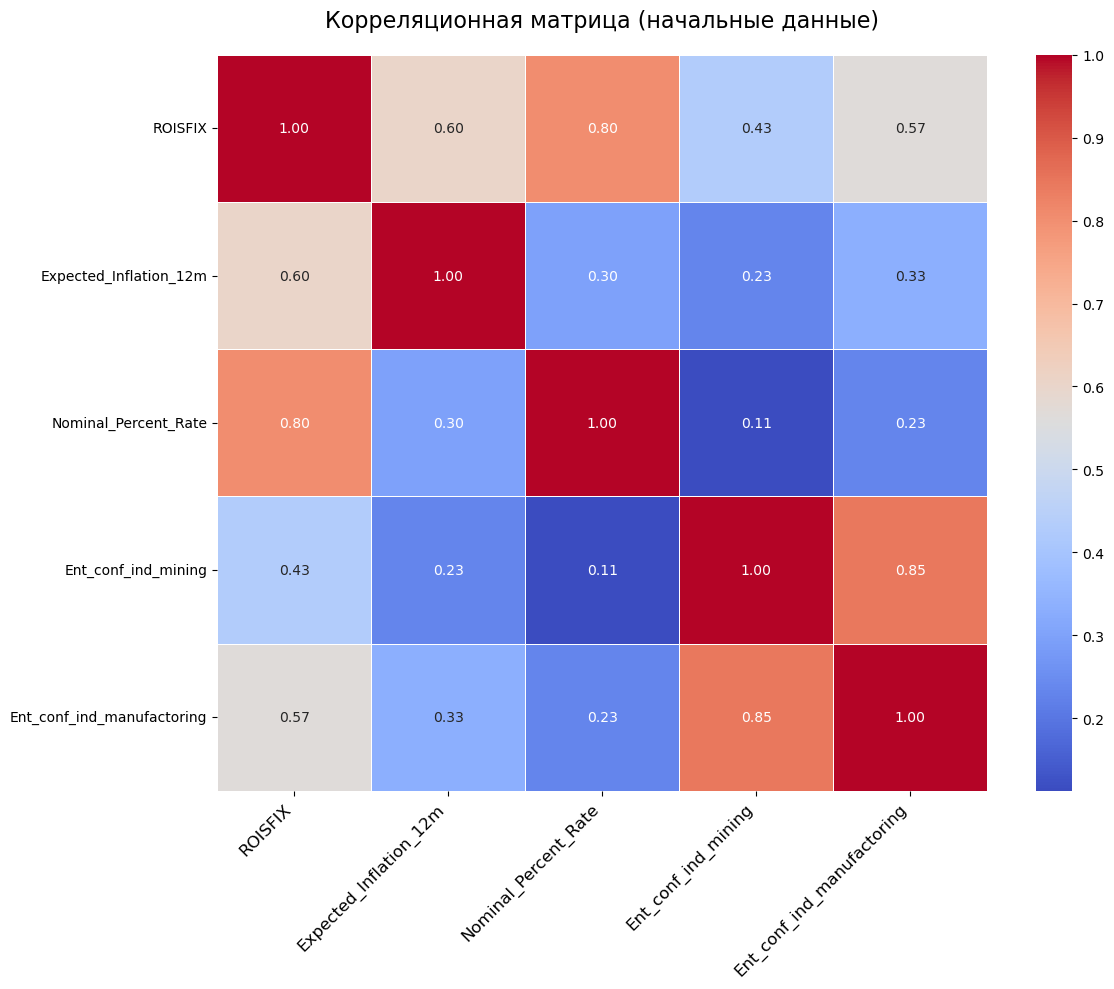

In [204]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [205]:
###############################
    #VIF-анализ - начальные данные
###############################

vif_variables = [
    'ROISFIX',
    'Expected_Inflation_12m',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_mining',
    'Ent_conf_ind_manufactoring'
]
df_vif = df_RF[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ДАННЫЕ
                  Variable      VIF
                   ROISFIX 8.158937
      Nominal_Percent_Rate 4.535009
Ent_conf_ind_manufactoring 4.486045
       Ent_conf_ind_mining 3.700143
    Expected_Inflation_12m 1.984513


In [206]:
##############################
# Тест Фридмана на сезонность
##############################

variables_for_analysis = [
    ('ROISFIX', 'Ключевая ставка (ROISFIX)'),
    ('Expected_Inflation_12m', 'Ожидаемая инфляция на 12м'),
    ('Nominal_Percent_Rate', 'Номинальная ставка'),
    ('Ent_conf_ind_mining', 'Индекс уверенности (добыча)'),
    ('Ent_conf_ind_manufactoring', 'Индекс уверенности (обработка)')
]

def friedman_seasonality_test(df, date_col='Date', value_col='Variable', 
                              test_name=None):

    df_test = df.copy()
    df_test['Month'] = df_test[date_col].dt.month
    df_test['Year'] = df_test[date_col].dt.year
    
    # Перевод в таблицу: года × месяцы
    pivot_data = df_test.pivot(index='Year', columns='Month', values=value_col)
    
    # Удаляем строки с NaN (неполные годы)
    pivot_data = pivot_data.dropna()
    
    # Проверяем достаточность данных
    if len(pivot_data) < 3:
        print(f"{test_name}: Недостаточно лет ({len(pivot_data)}), минимум 3")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': 'Недостаточно данных'
        }
    
    try:
        # Тест Фридмана
        stat, p_value = friedmanchisquare(*[pivot_data[m].values for m in pivot_data.columns])
        
        # Определяем наличие сезонности
        has_seasonality = p_value < 0.05
        
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': stat,
            'p_value': p_value,
            'has_seasonality': has_seasonality,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': None
        }
    
    except Exception as e:
        print(f"Ошибка для {test_name}: {str(e)}")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': str(e)
        }



In [207]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))

    



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                      Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
     Ключевая ставка (ROISFIX)     4.456963 0.954598            False        5        12
     Ожидаемая инфляция на 12м    23.861538 0.013330             True        5        12
            Номинальная ставка    11.863422 0.373996            False        5        12
   Индекс уверенности (добыча)    21.098503 0.032365             True        5        12
Индекс уверенности (обработка)    27.583969 0.003747             True        5        12


[Ent_conf_ind_mining] Период: 2019-02, наблюдений: 81
[Ent_conf_ind_mining] Ошибка: [Errno 2] No such file or directory: 'C:\\Users\\Admin\\AppData\\Local\\Temp\\tmp4zdwpgxp.d13'
[Ent_conf_ind_manufactoring] Период: 2019-02, наблюдений: 81
[Ent_conf_ind_manufactoring] Сезонная корректировка выполнена
[Ent_conf_ind_manufactoring] Снижение волатильности: 5.8%

ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ В DF_RF
Ent_conf_ind_manufactoring_adj: 81 не-NaN значений
Ent_conf_ind_manufactoring_trend: 81 не-NaN значений
Ent_conf_ind_manufactoring_seasonal: 81 не-NaN значений

Всего добавлено столбцов: 3

СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКЦИИ
                    Переменная Снижение волатильности До корректировки После корректировки
Индекс уверенности (обработка)                   5.8%           3.3991              3.2006

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


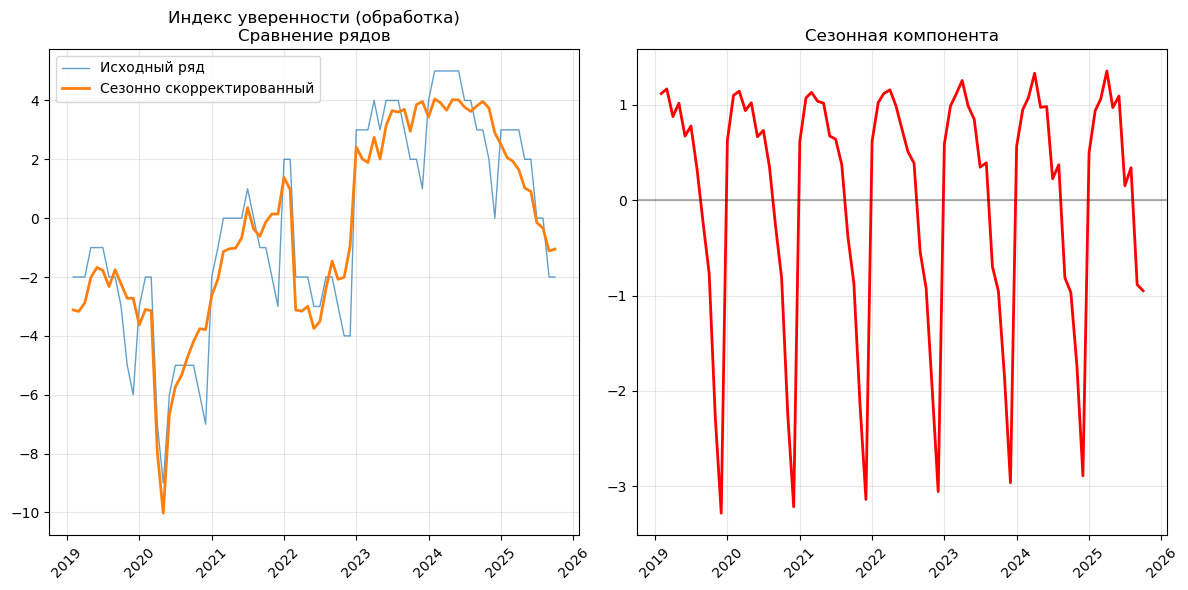

Все скорректированные ряды добавлены в df_RF
Столбцы с суффиксами: _adj, _trend, _seasonal


In [208]:
# Путь к бинарнику X-13
X13_PATH = 'C:\\Program Files (x86)\\x13as'   # либо каталог с бинарником, либо сам бинарник [web:2][web:8]

# Проверка, что бинарник доступен
if not os.path.exists(X13_PATH):
    raise FileNotFoundError(f"X-13 binary not found at {X13_PATH}")

# Если X13_PATH — полный путь к бинарнику, берем его директорию для x12path
x13_dir = X13_PATH if os.path.isdir(X13_PATH) else os.path.dirname(X13_PATH)

# Переменные для сезонной корректировки
x13_variables = {
     #'Expected_Inflation_12m': 'Ожидаемая инфляция (12м)',
    'Ent_conf_ind_mining': 'Индекс уверенности (добыча)',
    'Ent_conf_ind_manufactoring': 'Индекс уверенности (обработка)'
}

os.makedirs("x13_logs", exist_ok=True)

for col, name in x13_variables.items():
    try:
        # Подготовка данных
        series_data = df_RF[['Date', col]].copy().dropna()

        if len(series_data) < 24:
            print(f"[{col}] Недостаточно данных ({len(series_data)} наблюдений). Пропуск.")
            continue

        # Устанавливаем Date как индекс и приводим к месячной частоте (start of month)
        temp_df = series_data.set_index('Date').asfreq('MS').dropna()

        if len(temp_df) < 24:
            print(f"[{col}] Менее 24 наблюдений после asfreq/NA. Пропуск.")
            continue

        print(f"[{col}] Период: {temp_df.index[0].year}-{temp_df.index[0].month:02d}, "
              f"наблюдений: {len(temp_df)}")

        # Вектор значений как pandas.Series с DatetimeIndex
        ts = temp_df[col]

        # Запуск X-13 (аналог seasonal::seas с SEATS)
        # По умолчанию statsmodels использует X-11; для полной эквивалентности
        # с SEATS могут потребоваться кастомные спецификации, но базовая декомпозиция
        # (seasadj, trend, irregular) доступна сразу. [web:2][web:8]
        res = x13_arima_analysis(
            endog=ts,
            x12path=x13_dir,
            prefer_x13=True,
            outlier=True,
            trading=False,
            print_stdout=False
        )

        # Компоненты (названия полей см. в документации statsmodels.X13ArimaAnalysisResult) [web:2][web:8]
        # seasadj: seasonally adjusted
        # trend: trend-cycle
        # irregular: остаток; сезонная компонента = исходный ряд - seasadj
        adj = res.seasadj
        trend = res.trend
        seas = ts - adj

        # Приведение к общему датафрейму
        df_RF.set_index('Date', inplace=True)

        # Создаем столбцы и заполняем только на пересечении индексов
        common_index = df_RF.index.intersection(ts.index)

        df_RF.loc[common_index, f'{col}_adj'] = adj.reindex(common_index)
        df_RF.loc[common_index, f'{col}_trend'] = trend.reindex(common_index)
        df_RF.loc[common_index, f'{col}_seasonal'] = seas.reindex(common_index)

        # Возвращаем индекс Date в столбец (если нужно)
        df_RF.reset_index(inplace=True)

        # Расчет эффективности (снижение волатильности)
        mask = ~df_RF[f'{col}_adj'].isna()
        if mask.any():
            original_std = df_RF.loc[mask, col].std()
            adj_std = df_RF.loc[mask, f'{col}_adj'].std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0

            print(f"[{col}] Сезонная корректировка выполнена")
            print(f"[{col}] Снижение волатильности: {reduction:.1f}%")

    except Exception as e:
        print(f"[{col}] Ошибка: {e}")


# === ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ ===
print("\n" + "="*60)
print("ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ В DF_RF")
print("="*60)

added_columns = []
for col in x13_variables.keys():
    for suffix in ['_adj', '_trend', '_seasonal']:
        new_col = f'{col}{suffix}'
        if new_col in df_RF.columns:
            added_columns.append(new_col)
            non_na_count = df_RF[new_col].notna().sum()
            print(f"{new_col}: {non_na_count} не-NaN значений")

print(f"\nВсего добавлено столбцов: {len(added_columns)}")

# === СВОДКА РЕЗУЛЬТАТОВ ===
print("\n" + "="*60)
print("СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКЦИИ")
print("="*60)

results_summary = []
for col, name in x13_variables.items():
    adj_col = f'{col}_adj'
    if adj_col in df_RF.columns:
        mask = ~df_RF[adj_col].isna()
        if mask.any():
            original_data = df_RF.loc[mask, col]
            adj_data = df_RF.loc[mask, adj_col]

            original_std = original_data.std()
            adj_std = adj_data.std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0

            results_summary.append({
                'Переменная': name,
                'Снижение волатильности': f"{reduction:.1f}%",
                'До корректировки': f"{original_std:.4f}",
                'После корректировки': f"{adj_std:.4f}"
            })

if results_summary:
    summary_df = pd.DataFrame(results_summary)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)

for col, name in x13_variables.items():
    adj_col = f'{col}_adj'
    if adj_col in df_RF.columns:
        plot_data = df_RF[['Date', col, adj_col]].dropna(subset=[adj_col])

        if len(plot_data) > 0:
            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.plot(plot_data['Date'], plot_data[col],
                     label='Исходный ряд', alpha=0.7, linewidth=1)
            plt.plot(plot_data['Date'], plot_data[adj_col],
                     label='Сезонно скорректированный', linewidth=2)
            plt.title(f'{name}\nСравнение рядов')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.xticks(rotation=45)

            plt.subplot(1, 2, 2)
            seasonal_col = f'{col}_seasonal'
            if seasonal_col in df_RF.columns:
                seasonal_data = df_RF[['Date', seasonal_col]].dropna(subset=[seasonal_col])
                plt.plot(seasonal_data['Date'], seasonal_data[seasonal_col],
                         color='red', linewidth=2)
                plt.title('Сезонная компонента')
                plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
                plt.grid(alpha=0.3)
                plt.xticks(rotation=45)

            plt.tight_layout()
            plt.show()

print("Все скорректированные ряды добавлены в df_RF")
print("Столбцы с суффиксами: _adj, _trend, _seasonal")

In [209]:
df_RF.head()

,Date,Num_reg,Region,CAR_Indicator,D_Progr_mort,ROISFIX,exc_rate,exc_rate_diff,Bonds_Rate_Correct_5Y,Inflation_Expectations,...,Covid_dum,Sank_dum,Month,Year,pi_current_year,pi_next_year,Expected_Inflation_12m,Ent_conf_ind_manufactoring_adj,Ent_conf_ind_manufactoring_trend,Ent_conf_ind_manufactoring_seasonal
0,2019-02-01,0,РОССИЯ,0.146150,0.013333,7.652000,65.810525,-0.702019,0.274500,10.362319,...,0,0,2,2019,10.362319,8.150424,10.177994,-3.118780,-3.161703,1.118780
1,2019-03-01,0,РОССИЯ,0.146823,0.014805,7.611500,65.092257,-0.718268,0.292500,10.144295,...,0,0,3,2019,10.144295,7.855319,9.762799,-3.167966,-2.871824,1.167966
2,2019-04-01,0,РОССИЯ,0.146778,0.017586,7.630000,64.603105,-0.489152,0.316818,9.004132,...,0,0,4,2019,9.004132,7.845972,8.714592,-2.877533,-2.571156,0.877533
3,2019-05-01,0,РОССИЯ,0.145500,0.019362,7.635556,64.818706,0.215601,0.295714,9.416996,...,0,0,5,2019,9.416996,8.881323,9.238438,-2.018658,-2.289942,1.018658
4,2019-06-01,0,РОССИЯ,0.144882,0.027592,7.524737,64.169050,-0.649656,0.197895,9.280142,...,0,0,6,2019,9.280142,9.262617,9.272840,-1.672649,-2.049704,0.672649


In [210]:
##############################
# Тест Фридмана для рядов, скорректированных на сезонность
##############################

variables_for_analysis = [
    ('Ent_conf_ind_mining_adj', 'Индекс уверенности (добыча)'),
    ('Ent_conf_ind_manufactoring_adj', 'Индекс уверенности (обработка)')
]

def friedman_seasonality_test(df, date_col='Date', value_col='Variable', 
                              test_name=None):

    df_test = df.copy()
    df_test['Month'] = df_test[date_col].dt.month
    df_test['Year'] = df_test[date_col].dt.year
    
    # Перевод в таблицу: года × месяцы
    pivot_data = df_test.pivot(index='Year', columns='Month', values=value_col)
    
    # Удаляем строки с NaN (неполные годы)
    pivot_data = pivot_data.dropna()
    
    # Проверяем достаточность данных
    if len(pivot_data) < 3:
        print(f"{test_name}: Недостаточно лет ({len(pivot_data)}), минимум 3")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': 'Недостаточно данных'
        }
    
    try:
        # Тест Фридмана
        stat, p_value = friedmanchisquare(*[pivot_data[m].values for m in pivot_data.columns])
        
        # Определяем наличие сезонности
        has_seasonality = p_value < 0.05
        
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': stat,
            'p_value': p_value,
            'has_seasonality': has_seasonality,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': None
        }
    
    except Exception as e:
        print(f"Ошибка для {test_name}: {str(e)}")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': str(e)
        }



In [211]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*60)
print(friedman_summary.to_string(index=False))

    



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                      Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
Индекс уверенности (обработка)    10.692308 0.469389            False        5        12


In [212]:
print("\n" + "="*60)
print("РАСЧЕТ ИНДЕКСА ПРЕДПРИНИМАТЕЛЬСКОЙ УВЕРЕННОСТИ")
print("="*60)

# Веса по доле в структуре промышленности РФ (2023 г.)
weights = {
    'mining': 0.47,              # Добывающая промышленность: 47%
    'manufacturing': 0.53        # Обрабатывающая промышленность: 53%
}

mining_col = 'Ent_conf_ind_mining_adj'
manuf_col = 'Ent_conf_ind_manufactoring_adj'

# Проверяем доступность
mining_available = mining_col in df_RF.columns
manuf_available = manuf_col in df_RF.columns


if mining_available and manuf_available:
    # Берем скорректированные данные
    mining_series = df_RF[mining_col].copy()
    manuf_series = df_RF[manuf_col].copy()
    
    # Расчет взвешенного среднего
    df_RF['Ent_conf_ind_total'] = (
        weights['mining'] * mining_series + 
        weights['manufacturing'] * manuf_series
    )    

# Корреляция итогового индекса с компонентами
corr_total_mining = df_RF['Ent_conf_ind_total'].corr(mining_series)
corr_total_manuf = df_RF['Ent_conf_ind_total'].corr(manuf_series)

print(f"\nКорреляция итогового индекса с компонентами:")
print(f"  Итоговый - Добыча: {corr_total_mining:.4f}")
print(f"  Итоговый - Обработка: {corr_total_manuf:.4f}")


fig, ax1 = plt.subplots(figsize=(15, 6))

# График: Компоненты и итоговый индекс
ax1.plot(df_RF['Date'], mining_series, 
         label='Добывающая промышленность', linewidth=2, alpha=0.8, color='steelblue')
ax1.plot(df_RF['Date'], manuf_series, 
         label='Обрабатывающая промышленность', linewidth=2, alpha=0.8, color='orange')
ax1.plot(df_RF['Date'], df_RF['Ent_conf_ind_total'], 
         label='Итоговый индекс', 
         linewidth=2.5, color='darkred', linestyle='-', marker='o', markersize=3)

ax1.set_title('Индекс предпринимательской уверенности: компоненты и агрегат', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('Индекс', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


РАСЧЕТ ИНДЕКСА ПРЕДПРИНИМАТЕЛЬСКОЙ УВЕРЕННОСТИ


KeyError: 'Ent_conf_ind_total'

In [ ]:
target_inflation = 4.0
df_RF['Inflation_gap'] =  df_RF['Expected_Inflation_12m'] - target_inflation

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_RF['Date'], df_RF['Inflation_gap'], 
         linewidth=2.5, color='darkred', linestyle='-', marker='o', markersize=3)
ax1.set_title('Инфляционный разрыв', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('%', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

In [ ]:
df_taylor = df_RF[['Date','ROISFIX', 'Inflation_gap', 'Nominal_Percent_Rate', 'Ent_conf_ind_total', 'Expected_Inflation_12m']]
df_taylor.head()

In [ ]:
###############################
# Тест Льюинга-Бокса до перехода к разностям
###############################

# === ПЕРЕМЕННЫЕ ДЛЯ ТЕСТА ===
test_variables = {
    'ROISFIX': 'Ставка ROISFIX',
    'Inflation_gap': 'Инфляционный разрыв',
    'Nominal_Percent_Rate': 'Нейтральная ставка',
    'Ent_conf_ind_total': 'Индекс уверенности'
}

# === ФУНКЦИЯ 1: Определяет какой ряд использовать (adj или исходный) ===
def get_series_for_test(df, col_name):
    """
    Проверяет наличие скорректированного ряда (_adj).
    Если есть → возвращает его, иначе возвращает исходный.
    
    Returns:
    --------
    tuple: (series, source_type)
        series : pd.Series - временной ряд
        source_type : str - "Сезонно-скорректированный" или "Исходный"
    """
    
    adj_col = f'{col_name}_adj'
    
    # Проверяем наличие adj столбца и его наполненность
    if adj_col in df.columns:
        adj_series = df[adj_col].dropna()
        if len(adj_series) > 0:
            return adj_series, "Сезонно-скорректированный"
    
    # Если adj не существует или пуст - берем исходный
    original_series = df[col_name].dropna()
    return original_series, "Исходный"

# === ФУНКЦИЯ 2: Тест Льюинга-Бокса ===
def optimized_ljung_box_test(series, name, source_type, max_lags=None):
    """
    Тест Льюинга-Бокса с автоматическим подбором лагов
    
    Parameters:
    -----------
    series : pd.Series или array-like
        Временной ряд для тестирования
    name : str
        Название переменной
    source_type : str
        "Сезонно-скорректированный" или "Исходный"
    max_lags : int, optional
        Максимальное количество лагов
    
    Returns:
    --------
    dict : результаты теста
    """
    
    if len(series) < 30:
        lags = min(10, len(series) - 1)
    else:
        # Автоматический подбор лагов: sqrt(n) + 10 для месячных данных
        lags = min(int(np.sqrt(len(series))) + 10, len(series) - 1)
    
    if max_lags:
        lags = min(lags, max_lags)
    
    # Минимальное количество лагов для теста
    lags = max(5, lags)
    
    try:
        # Основной тест на выбранных лагах
        result = acorr_ljungbox(series, lags=[lags], return_df=True)
        lb_stat = result['lb_stat'].iloc[0]
        lb_pvalue = result['lb_pvalue'].iloc[0]
        
        # Дополнительно проверяем несколько ключевых лагов
        key_lags = [1, 3, 6, 12]
        key_results = []
        
        for lag in key_lags:
            if lag <= lags:
                res = acorr_ljungbox(series, lags=[lag], return_df=True)
                key_results.append({
                    'lag': lag,
                    'pvalue': res['lb_pvalue'].iloc[0]
                })
        
        return {
            'name': name,
            'source_type': source_type,
            'n_obs': len(series),
            'test_lags': lags,
            'lb_statistic': lb_stat,
            'p_value': lb_pvalue,
            'is_white_noise': lb_pvalue > 0.05,
            'key_lags_results': key_results,
            'series': series  # для визуализации
        }
    
    except Exception as e:
        print(f"Ошибка в тесте для {name} ({source_type}): {e}")
        return None

# === ОСНОВНОЙ АНАЛИЗ ===


ljungbox_results = []
problematic_series = []

for col, name in test_variables.items():
    if col not in df_taylor.columns:
        print(f"✗ {name}: столбец '{col}' не найден в df_taylor")
        continue
    
    # Определяем какой ряд использовать
    series, source_type = get_series_for_test(df_taylor, col)
    
    if len(series) < 10:
        print(f"✗ {name}: недостаточно данных (n={len(series)})")
        continue
    
    # Выполняем тест
    result = optimized_ljung_box_test(series, name, source_type)
    
    if result:
        ljungbox_results.append(result)

# === ВЫВОД РЕЗУЛЬТАТОВ ===

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА")
print("="*70)

if ljungbox_results:
    for i, result in enumerate(ljungbox_results, 1):
        print(f"\n{i}. {result['name']}")
        print(f"   Тип данных: {result['source_type']}")
        print(f"   Наблюдения: {result['n_obs']}")
        print(f"   Тестовые лаги: {result['test_lags']}")
        print(f"   Ljung-Box статистика: {result['lb_statistic']:.3f}")
        print(f"   P-значение: {result['p_value']:.6f}")
        
        if result['is_white_noise']:
            print(f"   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)")
        else:
            print(f"   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)")
            problematic_series.append(result)
        
        # Ключевые лаги
        print(f"   Ключевые лаги:")
        for key_res in result['key_lags_results']:
            sig_mark = "✓" if key_res['pvalue'] > 0.05 else "✗"
            print(f"     Лаг {key_res['lag']:2d}: p={key_res['pvalue']:.6f} {sig_mark}")

# === СВОДНАЯ ТАБЛИЦА ===

if ljungbox_results:
    print("\n" + "="*70)
    print("СВОДНАЯ ТАБЛИЦА")
    print("="*70)
    
    summary_data = []
    for result in ljungbox_results:
        # Подсчитываем количество значимых лагов из ключевых
        sig_lags = sum(1 for res in result['key_lags_results'] if res['pvalue'] < 0.05)
        total_lags = len(result['key_lags_results'])
        
        # Определяем статус
        if result['is_white_noise']:
            status = "✓ OK"
        elif sig_lags <= 2:
            status = "⚠ Приемлемо"
        else:
            status = "✗ Проблема"
        
        summary_data.append({
            'Переменная': result['name'],
            'Тип данных': result['source_type'],
            'N': result['n_obs'],
            'P-значение': f"{result['p_value']:.6f}",
            'Значимые лаги': f"{sig_lags}/{total_lags}",
            'Статус': status
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ ACF/PACF ДЛЯ ПРОБЛЕМНЫХ РЯДОВ ===

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ ACF/PACF")
print("="*70)

# Визуализируем только для проблемных рядов
if problematic_series:
    for result in problematic_series:
        col_name = None
        for col, name in test_variables.items():
            if name == result['name']:
                col_name = col
                break
        
        if col_name:
            series = result['series']
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # ACF
            plot_acf(series, lags=min(20, len(series)-1), ax=axes[0], alpha=0.05)
            axes[0].set_title(f'ACF: {result["name"]} ({result["source_type"]})')
            axes[0].grid(alpha=0.3)
            
            # PACF
            plot_pacf(series, lags=min(20, len(series)-1), ax=axes[1], alpha=0.05)
            axes[1].set_title(f'PACF: {result["name"]} ({result["source_type"]})')
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
else:
    print("\n✓ Нет проблемных рядов - все переменные имеют приемлемый уровень автокорреляции!")

In [ ]:
###############################
    #Тесты на стационарность до перехода к разностям
###############################
variables_to_test = [
    'ROISFIX',
    'Inflation_gap',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_total',
    'Expected_Inflation_12m'
]

df_test = df_taylor[variables_to_test]

def stationarity_tests(series, name):
    series_clean = series.dropna()
    #ADF
    try:
        adf_result = adfuller(series_clean, autolag = 'BIC')
        adf_stat = adf_result[0]
        adf_pvalue = adf_result[1]
        adf_critical_one = adf_result[4]['1%']
        adf_critical_five = adf_result[4]['5%']
        adf_critical_ten = adf_result[4]['10%']
        adf_stationary = adf_pvalue < 0.05
    except Exception as e:
        adf_stat, adf_pvalue, adf_critical_one, adf_critical_five, adf_critical_ten, adf_stationary = (
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        )

    #KPSS
    try:
        kpss_result = kpss(series_clean, regression='c', nlags='auto')
        kpss_stat = kpss_result[0]
        kpss_pvalue = kpss_result[1]
        kpss_critical_one = kpss_result[3]['1%']
        kpss_critical_five = kpss_result[3]['5%']
        kpss_critical_ten = kpss_result[3]['10%']
        kpss_stationary = kpss_pvalue > 0.05  # H0: stationary
    except:
        kpss_stat, kpss_pvalue, kpss_critical_one, kpss_critical_five, kpss_critical_ten, kpss_stationary = (
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        )
  #DF-GLS
    try:
        DF_GLS_result = au.DFGLS(series_clean, trend='c', max_lags = 2, method = 'bic')
        DF_GLS_stat = DF_GLS_result.stat
        DF_GLS_pvalue = DF_GLS_result.pvalue
        DF_GLS_critical_one =  DF_GLS_result.critical_values['1%']
        DF_GLS_critical_five = DF_GLS_result.critical_values['5%']
        DF_GLS_critical_ten = DF_GLS_result.critical_values['10%']
        DF_GLS_stationary = DF_GLS_pvalue < 0.05  
    except:
        DF_GLS_stat, DF_GLS_pvalue, DF_GLS_critical_one, DF_GLS_critical_five, DF_GLS_critical_ten, DF_GLS_stationary = (
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        )  
    return {
        'Variable': name,
        #ADF
        'ADF_Statistic': adf_stat,
        'ADF_p_value': adf_pvalue,
        'ADF_Critical_1%': adf_critical_one,
        'ADF_Critical_5%': adf_critical_five,
        'ADF_Critical_10%': adf_critical_ten,
        'ADF_Stationary': adf_stationary,
        #KPSS
        'KPSS_Statistic': kpss_stat,
        'KPSS_p_value': kpss_pvalue,
        'KPSS_Critical_1%': kpss_critical_one,
        'KPSS_Critical_5%': kpss_critical_five,
        'KPSS_Critical_10%': kpss_critical_ten,
        'KPSS_Stationary': kpss_stationary,
        # DF-GLS
        'DF_GLS_Statistic': DF_GLS_stat,
        'DF_GLS_p_value': DF_GLS_pvalue,
        'DF_GLS_Critical_1%': DF_GLS_critical_one,
        'DF_GLS_Critical_5%': DF_GLS_critical_five,
        'DF_GLS_Critical_10%': DF_GLS_critical_ten,
        'DF_GLS_Stationary': DF_GLS_stationary
    }
stationarity_results = []
for var in df_test.columns:
    result = stationarity_tests(df_test[var], var)
    stationarity_results.append(result)

stationarity_df = pd.DataFrame(stationarity_results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ НА СТАЦИОНАРНОСТЬ ДЛЯ НАЧАЛЬНЫХ ДАННЫХ")
print("="*60)
print(stationarity_df.to_string())

In [ ]:
###############################
    #Логарифмирование + приведение к первым разностям
###############################
log_vars = {
    'ROISFIX': 'log_ROISFIX',
    'Nominal_Percent_Rate': 'log_Nominal_Percent_Rate'
}

df_log = df_taylor[['Date'] + list(log_vars.keys())].copy()

for var, log_name in log_vars.items():
    if (df_taylor[var] > 0).all():
        df_log[log_name] = np.log(df_taylor[var])
            
# Не логарифмируем т.к. в % и есть значения <0
no_log_vars = ['Inflation_gap', 'Ent_conf_ind_total', 'Expected_Inflation_12m']
df_log['Inflation_gap'] = df_taylor['Inflation_gap']
df_log['Expected_Inflation_12m'] = df_taylor['Expected_Inflation_12m']
df_log['Ent_conf_ind_total'] = df_taylor['Ent_conf_ind_total']

df_diff = df_log.copy()

# Первая разность логарифмов
for log_name in df_log.columns[1:]:
    if log_name.startswith('log_'):
        diff_name = f"D_{log_name}"
        df_diff[diff_name] = df_log[log_name].diff()

# Первая разность не log
for var in no_log_vars:
    if var in df_log.columns:
        diff_name = f"D_{var}"
        df_diff[diff_name] = df_log[var].diff()

columns_to_keep = ['Date'] + [f"D_{name}" for name in df_log.columns[1:] if name.startswith('log_')] + [f"D_{var}" for var in no_log_vars]
df_diff = df_diff[columns_to_keep]

df_diff = df_diff.dropna()
df_diff.head()

In [ ]:
###############################
    #Тесты на стационарность для I(1) переменных
###############################
diff_vars = [col for col in df_diff.columns if col.startswith('D_')]
stationarity_results_diff = []


for var in diff_vars:
    result = stationarity_tests(df_diff[var], var)
    stationarity_results_diff.append(result)

stationarity_df_diff = pd.DataFrame(stationarity_results_diff)
print(stationarity_df_diff.to_string())

In [ ]:
df_taylor = df_diff.copy()

In [ ]:
###############################
# Тест Льюинга-Бокса для I(1) переменных
###############################

# === ПЕРЕМЕННЫЕ ДЛЯ ТЕСТА ===
test_variables = {
    'D_log_ROISFIX': 'Логарифм I(1) ставки ROISFIX',
    'D_Inflation_gap': 'I(1) инфляционный разрыв',
    'D_log_Nominal_Percent_Rate': 'Логарифм I(1) нейтральной ставки',
    'D_Ent_conf_ind_total': 'I(1) индекс уверенности'
}

# === ФУНКЦИЯ 1: Определяет какой ряд использовать (adj или исходный) ===
def get_series_for_test(df, col_name):
    """
    Проверяет наличие скорректированного ряда (_adj).
    Если есть → возвращает его, иначе возвращает исходный.
    
    Returns:
    --------
    tuple: (series, source_type)
        series : pd.Series - временной ряд
        source_type : str - "Сезонно-скорректированный" или "Исходный"
    """
    
    adj_col = f'{col_name}_adj'
    
    # Проверяем наличие adj столбца и его наполненность
    if adj_col in df.columns:
        adj_series = df[adj_col].dropna()
        if len(adj_series) > 0:
            return adj_series, "Сезонно-скорректированный"
    
    # Если adj не существует или пуст - берем исходный
    original_series = df[col_name].dropna()
    return original_series, "Исходный"

# === ФУНКЦИЯ 2: Тест Льюинга-Бокса ===
def optimized_ljung_box_test(series, name, source_type, max_lags=None):
    """
    Тест Льюинга-Бокса с автоматическим подбором лагов
    
    Parameters:
    -----------
    series : pd.Series или array-like
        Временной ряд для тестирования
    name : str
        Название переменной
    source_type : str
        "Сезонно-скорректированный" или "Исходный"
    max_lags : int, optional
        Максимальное количество лагов
    
    Returns:
    --------
    dict : результаты теста
    """
    
    if len(series) < 30:
        lags = min(10, len(series) - 1)
    else:
        # Автоматический подбор лагов: sqrt(n) + 10 для месячных данных
        lags = min(int(np.sqrt(len(series))) + 10, len(series) - 1)
    
    if max_lags:
        lags = min(lags, max_lags)
    
    # Минимальное количество лагов для теста
    lags = max(5, lags)
    
    try:
        # Основной тест на выбранных лагах
        result = acorr_ljungbox(series, lags=[lags], return_df=True)
        lb_stat = result['lb_stat'].iloc[0]
        lb_pvalue = result['lb_pvalue'].iloc[0]
        
        # Дополнительно проверяем несколько ключевых лагов
        key_lags = [1, 3, 6, 12]
        key_results = []
        
        for lag in key_lags:
            if lag <= lags:
                res = acorr_ljungbox(series, lags=[lag], return_df=True)
                key_results.append({
                    'lag': lag,
                    'pvalue': res['lb_pvalue'].iloc[0]
                })
        
        return {
            'name': name,
            'source_type': source_type,
            'n_obs': len(series),
            'test_lags': lags,
            'lb_statistic': lb_stat,
            'p_value': lb_pvalue,
            'is_white_noise': lb_pvalue > 0.05,
            'key_lags_results': key_results,
            'series': series  # для визуализации
        }
    
    except Exception as e:
        print(f"Ошибка в тесте для {name} ({source_type}): {e}")
        return None

# === ОСНОВНОЙ АНАЛИЗ ===


ljungbox_results = []
problematic_series = []

for col, name in test_variables.items():
    if col not in df_taylor.columns:
        print(f"✗ {name}: столбец '{col}' не найден в df_taylor")
        continue
    
    # Определяем какой ряд использовать
    series, source_type = get_series_for_test(df_taylor, col)
    
    if len(series) < 10:
        print(f"✗ {name}: недостаточно данных (n={len(series)})")
        continue
    
    # Выполняем тест
    result = optimized_ljung_box_test(series, name, source_type)
    
    if result:
        ljungbox_results.append(result)

# === ВЫВОД РЕЗУЛЬТАТОВ ===

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА")
print("="*70)

if ljungbox_results:
    for i, result in enumerate(ljungbox_results, 1):
        print(f"\n{i}. {result['name']}")
        print(f"   Тип данных: {result['source_type']}")
        print(f"   Наблюдения: {result['n_obs']}")
        print(f"   Тестовые лаги: {result['test_lags']}")
        print(f"   Ljung-Box статистика: {result['lb_statistic']:.3f}")
        print(f"   P-значение: {result['p_value']:.6f}")
        
        if result['is_white_noise']:
            print(f"   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)")
        else:
            print(f"   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)")
            problematic_series.append(result)
        
        # Ключевые лаги
        print(f"   Ключевые лаги:")
        for key_res in result['key_lags_results']:
            sig_mark = "✓" if key_res['pvalue'] > 0.05 else "✗"
            print(f"     Лаг {key_res['lag']:2d}: p={key_res['pvalue']:.6f} {sig_mark}")

# === СВОДНАЯ ТАБЛИЦА ===

if ljungbox_results:
    print("\n" + "="*70)
    print("СВОДНАЯ ТАБЛИЦА")
    print("="*70)
    
    summary_data = []
    for result in ljungbox_results:
        # Подсчитываем количество значимых лагов из ключевых
        sig_lags = sum(1 for res in result['key_lags_results'] if res['pvalue'] < 0.05)
        total_lags = len(result['key_lags_results'])
        
        # Определяем статус
        if result['is_white_noise']:
            status = "✓ OK"
        elif sig_lags <= 2:
            status = "⚠ Приемлемо"
        else:
            status = "✗ Проблема"
        
        summary_data.append({
            'Переменная': result['name'],
            'Тип данных': result['source_type'],
            'N': result['n_obs'],
            'P-значение': f"{result['p_value']:.6f}",
            'Значимые лаги': f"{sig_lags}/{total_lags}",
            'Статус': status
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ ACF/PACF ДЛЯ ПРОБЛЕМНЫХ РЯДОВ ===

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ ACF/PACF")
print("="*70)

# Визуализируем только для проблемных рядов
if problematic_series:
    for result in problematic_series:
        col_name = None
        for col, name in test_variables.items():
            if name == result['name']:
                col_name = col
                break
        
        if col_name:
            series = result['series']
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # ACF
            plot_acf(series, lags=min(20, len(series)-1), ax=axes[0], alpha=0.05)
            axes[0].set_title(f'ACF: {result["name"]} ({result["source_type"]})')
            axes[0].grid(alpha=0.3)
            
            # PACF
            plot_pacf(series, lags=min(20, len(series)-1), ax=axes[1], alpha=0.05)
            axes[1].set_title(f'PACF: {result["name"]} ({result["source_type"]})')
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
else:
    print("\n✓ Нет проблемных рядов - все переменные имеют приемлемый уровень автокорреляции!")

In [ ]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ
###############################
descriptive_df = df_taylor[[
    'D_log_ROISFIX',
    'D_Inflation_gap',
    'D_log_Nominal_Percent_Rate',
    'D_Ent_conf_ind_total'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])

In [ ]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ОБРАБОТАННЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (обработанные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [ ]:
###############################
    #VIF-анализ - обработанные данные
###############################

vif_variables = [
    'D_log_ROISFIX',
    'D_Inflation_gap',
    'D_log_Nominal_Percent_Rate',
    'D_Ent_conf_ind_total'
]
df_vif = df_taylor[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ОБРАБОТАННЫЕ ДАННЫЕ")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #Тест Йохансена на поиск коинтегрирующего соотношения
###############################
print("\n" + "="*60)
print("ТЕСТ ЙОХАНСЕНА")
print("="*60)

# === ДАННЫЕ В УРОВНЯХ ===
df_johansen = df_RF[['ROISFIX', 'Inflation_gap', 'Nominal_Percent_Rate', 'Ent_conf_ind_total']].dropna()

print(f"\nДанные: {len(df_johansen)} наблюдений")
print(f"Период: {df_RF['Date'].min()} - {df_RF['Date'].max()}")

# === ТЕСТ ЙОХАНСЕНА ===
print("\n" + "="*60)
print("Тестирование на коинтеграцию используемых временных рядов")
print("Результаты проведения теста Йохансена на поиск коинтегрирующего соотношения")
print("Статистика Trace Value")
print("="*60)

johansen = coint_johansen(df_johansen, det_order=0, k_ar_diff=1)

# Таблица результатов Trace test
print(f"\n{'r':<6} {'Test':<10} {'10%':<10} {'5%':<10} {'1%':<10} {'Result':<15}")
print("-"*60)

rank = 0
k = len(df_johansen.columns)

for r in range(k):
    stat = johansen.lr1[r]
    crit_10 = johansen.cvt[r, 0]
    crit_5 = johansen.cvt[r, 1]
    crit_1 = johansen.cvt[r, 2]
    
    # ПРАВИЛЬНАЯ логика определения ранга:
    # H0: ранг коинтеграции <= r
    # H1: ранг коинтеграции > r
    
    if stat > crit_5:
        result_text = "✓ Reject H0"
    else:
        result_text = "✗ Accept H0"
        rank = r
        break
else:
    # Если отвергли все гипотезы (для всех r от 0 до k-1), то ранг = k
    rank = k

print(f"{r:<6} {stat:<10.2f} {crit_10:<10.2f} {crit_5:<10.2f} {crit_1:<10.2f} {result_text:<15}")

# ВЫВОДИМ ВСЕ СТРОКИ ТАБЛИЦЫ ДЛЯ ПРОЗРАЧНОСТИ
for r_display in range(k):
    if r_display != r:  
        stat_display = johansen.lr1[r_display]
        crit_10_display = johansen.cvt[r_display, 0]
        crit_5_display = johansen.cvt[r_display, 1]
        crit_1_display = johansen.cvt[r_display, 2]
        
        if stat_display > crit_5_display:
            result_text_display = "✓ Reject H0"
        else:
            result_text_display = "✗ Accept H0"
            
        print(f"{r_display:<6} {stat_display:<10.2f} {crit_10_display:<10.2f} {crit_5_display:<10.2f} {crit_1_display:<10.2f} {result_text_display:<15}")

print(f"\n→ Ранг коинтеграции: r = {rank}")

# === ЛИНЕЙНАЯ КОМБИНАЦИЯ ИССЛЕДУЕМЫХ РЯДОВ ===
print("\n" + "="*60)
print("Линейная комбинация исследуемых рядов")
print("="*60)

if rank > 0:
    # Нормализуем первый собственный вектор (коинтеграционный вектор)
    beta = johansen.evec[:, 0].copy()
    beta = beta / beta[0]

    print(f"\nКоинтеграционный вектор (β):")
    print(f"(долгосрочное равновесное соотношение)\n")

    # Названия переменных как в таблице
    var_display_names = [
        'Key_Rate_t',
        'Inflation_Expectations_12m_t', 
        'Output_Gap_t',
        'Neutral_Rate_t'
    ]

    for i, display_name in enumerate(var_display_names):
        coef = beta[i]
        print(f"{display_name:<35} {coef:>15.7f}")
else:
    print("\nКоинтеграционные векторы не найдены")

In [ ]:
###############################
    #Подготовка финального датасета (добавляем дамми, лаги и прозведения)
###############################

df_taylor['Covid_dum'] = df_RF['Covid_dum']
df_taylor['Sank_dum'] = df_RF['Sank_dum']
df_taylor['L1_D_Inflation_gap'] = df_taylor['D_Inflation_gap'].shift(1)
df_taylor['L1_D_Ent_conf_ind_total'] = df_taylor['D_Ent_conf_ind_total'].shift(1)
df_taylor['L1_D_log_Nominal_Percent_Rate'] = df_taylor['D_log_Nominal_Percent_Rate'].shift(1)  
df_taylor['L1_D_log_ROISFIX'] = df_taylor['D_log_ROISFIX'].shift(1)

df_taylor = df_taylor.dropna()
df_taylor.head()

In [ ]:
###############################
# Тест White и Breusch-Pagan на гетероскедастичность
###############################
print("\n" + "="*60)
print("ТЕСТЫ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ: WHITE И BREUSCH-PAGAN")
print("="*60)

# Подготавливаем данные для регрессии
X = sm.add_constant(df_taylor[['D_Inflation_gap', 'D_log_Nominal_Percent_Rate', 'D_Ent_conf_ind_total']])
y = df_taylor['D_log_ROISFIX']

# Строим базовую модель OLS
model_ols = sm.OLS(y, X).fit()

# Получаем остатки
residuals = model_ols.resid

print("\nРегрессионная модель:")
print(f"Зависимая переменная: D_log_ROISFIX")
print(f"Количество наблюдений: {len(y)}")
print(f"R-squared: {model_ols.rsquared:.4f}")

# === ТЕСТ BREUSCH-PAGAN ===
print("\n" + "-"*60)
print("ТЕСТ BREUSCH-PAGAN")
print("-"*60)
print("H0: Гомоскедастичность (константная дисперсия)")
print("H1: Гетероскедастичность (переменная дисперсия)\n")

bp_stat, bp_pvalue, bp_f_stat, bp_f_pvalue = het_breuschpagan(residuals, X)

print(f"LM-статистика Breusch-Pagan: {bp_stat:.4f}")
print(f"P-значение (LM): {bp_pvalue:.6f}")
print(f"F-статистика: {bp_f_stat:.4f}")
print(f"P-значение (F): {bp_f_pvalue:.6f}")

if bp_pvalue < 0.05:
    print("\n ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)")
else:
    print("\n ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)")

# === ТЕСТ WHITE ===
print("\n" + "-"*80)
print("ТЕСТ WHITE")
print("-"*80)
print("H0: Гомоскедастичность (константная дисперсия)")
print("H1: Гетероскедастичность (переменная дисперсия)\n")

white_stat, white_pvalue, white_df, white_fitted = het_white(residuals, X)

print(f"LM-статистика White: {white_stat:.4f}")
print(f"P-значение: {white_pvalue:.6f}")
print(f"Степени свободы: {white_df}")

if white_pvalue < 0.05:
    print("\n ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)")
else:
    print("\n ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)")

# === СВОДНАЯ ТАБЛИЦА ===
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

summary_heteroscedasticity = pd.DataFrame({
    'Тест': ['Breusch-Pagan (LM)', 'Breusch-Pagan (F)', 'White'],
    'Статистика': [f"{bp_stat:.4f}", f"{bp_f_stat:.4f}", f"{white_stat:.4f}"],
    'P-значение': [f"{bp_pvalue:.6f}", f"{bp_f_pvalue:.6f}", f"{white_pvalue:.6f}"],
    'Вывод': [
        ' Гетероскедастичность' if bp_pvalue < 0.05 else ' Гомоскедастичность',
        ' Гетероскедастичность' if bp_f_pvalue < 0.05 else ' Гомоскедастичность',
        ' Гетероскедастичность' if white_pvalue < 0.05 else ' Гомоскедастичность'
    ]
})

print(summary_heteroscedasticity.to_string(index=False))

In [213]:
###############################
# ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ
###############################

def extract_ardl_coefficients(result, y_name, print_results=True):
    """
    Извлекает ключевые коэффициенты из ARDL модели:
    - α (alpha): реакция на инфляцию
    - μ (mu): реакция на уверенность
    - γ (gamma): коэффициент инерции (лаг зависимой переменной)
    """
    params = result.params
    pvalues = result.pvalues
    
    coeffs = {
        'alpha': None,
        'mu': None,
        'gamma': None,
        'alpha_pval': None,
        'mu_pval': None,
        'gamma_pval': None
    }
    
    # Извлечение альфа (инфляция)
    if 'D_Inflation_gap' in params.index:
        coeffs['alpha'] = params['D_Inflation_gap']
        coeffs['alpha_pval'] = pvalues['D_Inflation_gap']
    
    # Извлечение мю (уверенность)
    if 'D_Ent_conf_ind_total' in params.index:
        coeffs['mu'] = params['D_Ent_conf_ind_total']
        coeffs['mu_pval'] = pvalues['D_Ent_conf_ind_total']
    
    # Извлечение гамма (лаг зависимой переменной)
    # Ищем по паттерну: y_lag.1, L.y, D_log_ROISFIX.L1, etc.
    lag_patterns = [
    f'{y_name}.L1',
    f'L.{y_name}',
    f'{y_name}_lag',
    f'{y_name}_lag.1',
    f'{y_name}_L1',
    f'L1_{y_name}',
    ]
    
    for pattern in lag_patterns:
        if pattern in params.index:
            coeffs['gamma'] = params[pattern]
            coeffs['gamma_pval'] = pvalues[pattern]
            coeffs['gamma_name'] = pattern
            break
    
    # Вывод результатов
    if print_results:
        print("\n" + "="*60)
        print("ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL")
        print("="*60)
        
        # α - реакция на инфляцию
        if coeffs['alpha'] is not None:
            alpha_sr = coeffs['alpha']
            alpha_pval = coeffs['alpha_pval']
            sig_alpha = "***" if alpha_pval < 0.01 else ("**" if alpha_pval < 0.05 else "*" if alpha_pval < 0.1 else "")
            print(f"\nα (АЛЬФА) - краткосрочная реакция на инфляцию:")
            print(f"  Значение: {alpha_sr:.6f} {sig_alpha}")
            print(f"  P-value: {alpha_pval:.6f}")
            print(f"  Интерпретация: На 1% рост инфляции, ставка {'растет' if alpha_sr > 0 else 'падает'} на {abs(alpha_sr):.4f}%")
            if alpha_pval < 0.05:
                print(f"  Статистическая значимость: Значима (p < 0.05)")
            else:
                print(f"  Статистическая значимость: Незначима (p > 0.05)")
        else:
            print("\n α (альфа) не найдена в модели")
        
        # μ - реакция на уверенность
        if coeffs['mu'] is not None:
            mu_sr = coeffs['mu']
            mu_pval = coeffs['mu_pval']
            sig_mu = "***" if mu_pval < 0.01 else ("**" if mu_pval < 0.05 else "*" if mu_pval < 0.1 else "")
            print(f"\nμ (МЮ) - краткосрочная реакция на разрыв выпуска:")
            print(f"  Значение: {mu_sr:.6f} {sig_mu}")
            print(f"  P-value: {mu_pval:.6f}")
            print(f"  Интерпретация: На 1 пункт рост уверенности (прокси разрыва выпуска), ставка {'растет' if mu_sr > 0 else 'падает'} на {abs(mu_sr):.4f}%")
            if mu_pval < 0.05:
                print(f"  Статистическая значимость: Значима (p < 0.05)")
            else:
                print(f"  Статистическая значимость: Незначима (p > 0.05)")
        else:
            print("\n μ (мю) не найдена в модели")
        
        # γ - инерция (лагированная ставка)
        if coeffs['gamma'] is not None:
            gamma = coeffs['gamma']
            gamma_pval = coeffs['gamma_pval']
            speed_adj = 1 - gamma
            sig_gamma = "***" if gamma_pval < 0.01 else ("**" if gamma_pval < 0.05 else "*" if gamma_pval < 0.1 else "")
            
            print(f"\nγ (ГАММА) - коэффициент инерции (лаг зависимой переменной):")
            print(f"  Переменная: {coeffs.get('gamma_name', 'неизвестно')}")
            print(f"  Значение: {gamma:.6f} {sig_gamma}")
            print(f"  P-value: {gamma_pval:.6f}")
            
            print(f"\n  Интерпретация:")
            print(f"    - Инерция системы: {gamma:.4f} (доля предыдущего периода)")
            print(f"    - Скорость адаптации к равновесию: {speed_adj:.4f}")
            print(f"    - На каждый период корректируется: {speed_adj*100:.2f}% отклонения")
            
            if 0 < gamma < 1:
                print(f"    - Модель СТАБИЛЬНА (динамическое равновесие)")
            elif gamma >= 1:
                print(f"    -  Модель НЕСТАБИЛЬНА (взрывной процесс)")
            elif gamma < 0:
                print(f"    - ОТРИЦАТЕЛЬНАЯ инерция (колебания вокруг равновесия)")
        else:
            print("\n γ (гамма) не найдена в модели")
    
    return coeffs

In [214]:
###############################
# МОДЕЛЬ 1: БАЗОВАЯ (без dummy)
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 1: БАЗОВАЯ ARDL (1, 0, 0, 0) БЕЗ DUMMY")
print("="*60)

formula1 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate + 
            D_Ent_conf_ind_total
            """

model1 = ols(formula1, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model1.summary())
coeffs = extract_ardl_coefficients(model1, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 1: БАЗОВАЯ ARDL (1, 0, 0, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     6.524
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           0.000149
Time:                        14:44:41   Log-Likelihood:                 81.292
No. Observations:                  79   AIC:                            -152.6
Df Residuals:                      74   BIC:                            -140.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [215]:
###############################
# МОДЕЛЬ 2: с дамми для 2022 и для ковида
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 2: ARDL (1, 0, 0, 0) С DUMMY")
print("="*60)

formula2 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate + 
            D_Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model2 = ols(formula2, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model2.summary())
coeffs = extract_ardl_coefficients(model2, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 2: ARDL (1, 0, 0, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     5.176
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           0.000179
Time:                        14:44:41   Log-Likelihood:                 81.347
No. Observations:                  79   AIC:                            -148.7
Df Residuals:                      72   BIC:                            -132.1
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [216]:
###############################
# МОДЕЛЬ 3: с лагаом inf_gap разрыва без дамми 
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 3: ARDL (1, 1, 0, 0) БЕЗ DUMMY ")
print("="*60)

formula3 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total
            """

model3 = ols(formula3, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model3.summary())
coeffs = extract_ardl_coefficients(model3, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 3: ARDL (1, 1, 0, 0) БЕЗ DUMMY 
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     5.657
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           0.000183
Time:                        14:44:41   Log-Likelihood:                 82.663
No. Observations:                  79   AIC:                            -153.3
Df Residuals:                      73   BIC:                            -139.1
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [217]:
###############################
# МОДЕЛЬ 4: с лагом inf_gap разрыва с дамми 
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 4: ARDL (1, 1, 0, 0) С DUMMY ")
print("="*60)



formula4 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model4 = ols(formula4, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model4.summary())
coeffs = extract_ardl_coefficients(model4, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 4: ARDL (1, 1, 0, 0) С DUMMY 
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     4.595
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           0.000280
Time:                        14:44:41   Log-Likelihood:                 82.695
No. Observations:                  79   AIC:                            -149.4
Df Residuals:                      71   BIC:                            -130.4
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [218]:
###############################
# МОДЕЛЬ 5: ARDL с лагом r* без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 5: ARDL (1, 0, 1, 0) БЕЗ DUMMY")
print("="*60)

formula5 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total 
            """

model5 = ols(formula5, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model5.summary())
coeffs = extract_ardl_coefficients(model5, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 5: ARDL (1, 0, 1, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     10.39
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           1.50e-07
Time:                        14:44:41   Log-Likelihood:                 86.919
No. Observations:                  79   AIC:                            -161.8
Df Residuals:                      73   BIC:                            -147.6
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [219]:
###############################
# МОДЕЛЬ 6: ARDL с лагом r* С дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 6: ARDL (1, 0, 1, 0) С DUMMY")
print("="*60)

formula6 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model6 = ols(formula6, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model6.summary())
coeffs = extract_ardl_coefficients(model6, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 6: ARDL (1, 0, 1, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     7.648
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           7.34e-07
Time:                        14:44:41   Log-Likelihood:                 87.008
No. Observations:                  79   AIC:                            -158.0
Df Residuals:                      71   BIC:                            -139.1
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [220]:
###############################
# МОДЕЛЬ 7: ARDL с лагом y_gap БЕЗ дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 7: ARDL (1, 0, 0, 1) БЕЗ DUMMY")
print("="*60)

formula7 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total
            """

model7 = ols(formula7, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model6.summary())
coeffs = extract_ardl_coefficients(model6, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 7: ARDL (1, 0, 0, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     7.648
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           7.34e-07
Time:                        14:44:41   Log-Likelihood:                 87.008
No. Observations:                  79   AIC:                            -158.0
Df Residuals:                      71   BIC:                            -139.1
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [221]:
###############################
# МОДЕЛЬ 8: ARDL с лагом y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 8: ARDL (1, 0, 0, 1) С DUMMY")
print("="*60)

formula8 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model8 = ols(formula8, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model8.summary())
coeffs = extract_ardl_coefficients(model8, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 8: ARDL (1, 0, 0, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     6.297
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           9.27e-06
Time:                        14:44:41   Log-Likelihood:                 83.234
No. Observations:                  79   AIC:                            -150.5
Df Residuals:                      71   BIC:                            -131.5
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [222]:
###############################
# МОДЕЛЬ 9: ARDL с лагом inf_gap и r* без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 9: ARDL (1, 1, 1, 0) БЕЗ DUMMY")
print("="*60)

formula9 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap+
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate+
            D_Ent_conf_ind_total
            """

model9 = ols(formula9, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model9.summary())
coeffs = extract_ardl_coefficients(model9, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 9: ARDL (1, 1, 1, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     12.66
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           1.07e-09
Time:                        14:44:41   Log-Likelihood:                 89.852
No. Observations:                  79   AIC:                            -165.7
Df Residuals:                      72   BIC:                            -149.1
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [223]:
###############################
# МОДЕЛЬ 10: ARDL с лагом inf_gap и r* с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 10: ARDL (1, 1, 1, 0) С DUMMY")
print("="*60)

formula10 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap+
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate+
            D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model10 = ols(formula10, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model10.summary())
coeffs = extract_ardl_coefficients(model10, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 10: ARDL (1, 1, 1, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     10.02
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           3.48e-09
Time:                        14:44:41   Log-Likelihood:                 90.024
No. Observations:                  79   AIC:                            -162.0
Df Residuals:                      70   BIC:                            -140.7
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [224]:
###############################
# МОДЕЛЬ 11: ARDL с лагом inf_gap и y_gap без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 11: ARDL (1, 1, 0, 1) БЕЗ DUMMY")
print("="*60)

formula11 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total
            """

model11 = ols(formula11, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model11.summary())
coeffs = extract_ardl_coefficients(model11, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 11: ARDL (1, 1, 0, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     7.599
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           2.46e-06
Time:                        14:44:41   Log-Likelihood:                 84.743
No. Observations:                  79   AIC:                            -155.5
Df Residuals:                      72   BIC:                            -138.9
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [225]:
###############################
# МОДЕЛЬ 12: ARDL с лагом inf_gap и y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 12: ARDL (1, 1, 0, 1) С DUMMY")
print("="*60)

formula12 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model12 = ols(formula12, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model12.summary())
coeffs = extract_ardl_coefficients(model12, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 12: ARDL (1, 1, 0, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     6.686
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           1.80e-06
Time:                        14:44:41   Log-Likelihood:                 84.750
No. Observations:                  79   AIC:                            -151.5
Df Residuals:                      70   BIC:                            -130.2
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [226]:
###############################
# МОДЕЛЬ 13: ARDL с лагом r* и y_gap без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 13: ARDL (1, 0, 1, 1) БЕЗ DUMMY")
print("="*60)

formula13 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total
            """

model13 = ols(formula13, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model13.summary())
coeffs = extract_ardl_coefficients(model11, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 13: ARDL (1, 0, 1, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     11.39
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           6.52e-09
Time:                        14:45:22   Log-Likelihood:                 88.107
No. Observations:                  79   AIC:                            -162.2
Df Residuals:                      72   BIC:                            -145.6
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [227]:
###############################
# МОДЕЛЬ 14: ARDL с лагом inf_gap и y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 14: ARDL (1, 0, 1, 1) С DUMMY")
print("="*60)

formula14 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model14 = ols(formula14, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model14.summary())
coeffs = extract_ardl_coefficients(model14, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 14: ARDL (1, 0, 1, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     9.016
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           2.05e-08
Time:                        14:46:12   Log-Likelihood:                 88.225
No. Observations:                  79   AIC:                            -158.5
Df Residuals:                      70   BIC:                            -137.1
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [228]:
###############################
# МОДЕЛЬ 15: ARDL с лагами всех переменных без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 15: ARDL (1, 1, 1, 1) БЕЗ DUMMY")
print("="*60)

formula15 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total 
            """

model15 = ols(formula15, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model15.summary())
coeffs = extract_ardl_coefficients(model15, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 15: ARDL (1, 1, 1, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     14.09
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           2.57e-11
Time:                        14:46:43   Log-Likelihood:                 91.116
No. Observations:                  79   AIC:                            -166.2
Df Residuals:                      71   BIC:                            -147.3
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [229]:
###############################
# МОДЕЛЬ 16: ARDL ARDL с лагами всех переменных и дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 16: ARDL (1, 1, 1, 1) С DUMMY")
print("="*60)

formula16 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model16 = ols(formula16, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model16.summary())
coeffs = extract_ardl_coefficients(model16, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 16: ARDL (1, 1, 1, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     13.96
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           1.70e-12
Time:                        14:46:43   Log-Likelihood:                 91.345
No. Observations:                  79   AIC:                            -162.7
Df Residuals:                      69   BIC:                            -139.0
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [230]:
###############################
# СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
###############################


print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = [model1, model2, model3, model4,
          model5, model6, model7, model8,
          model9, model10, model11, model12,
          model13, model14, model15, model16]
model_names = ['Model 1/(1,0,0,0)', 'Model 2/(1,0,0,0)D', 
               'Model 3/(1,1,0,0)', 'Model 4/(1,1,0,0)D', 
               'Model 5/(1,0,1,0)', 'Model 6/(1,0,1,0)D',
               'Model 7/(1,0,0,1)', 'Model 8/(1,0,0,1)D',
               'Model 9/(1,1,1,0)', 'Model 10/(1,1,1,0)D', 
               'Model 11/(1,1,0,1)', 'Model 12/(1,1,0,1)D', 
               'Model 13/(1,0,1,1)', 'Model 14/(1,0,1,1)D',
               'Model 15/(1,1,1,1)', 'Model 16/(1,1,1,1)D'
              ]

comparison_data = {
    'Model': model_names,
    'R²': [m.rsquared for m in models],
    'Adj-R²': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models],
    'F-stat': [m.fvalue for m in models],
    'N': [len(m.resid) for m in models]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
              Model       R²   Adj-R²         AIC         BIC    F-stat  N
  Model 1/(1,0,0,0) 0.442626 0.412498 -152.583702 -140.736463  6.524041 79
 Model 2/(1,0,0,0)D 0.443399 0.397016 -148.693307 -132.107172  5.176147 79
  Model 3/(1,1,0,0) 0.461641 0.424767 -153.325830 -139.109143  5.657261 79
 Model 4/(1,1,0,0)D 0.462073 0.409038 -149.389222 -130.433639  4.594690 79
  Model 5/(1,0,1,0) 0.516638 0.483531 -161.838878 -147.622190 10.386683 79
 Model 6/(1,0,1,0)D 0.517726 0.470178 -158.016941 -139.061358  7.647867 79
  Model 7/(1,0,0,1) 0.469155 0.432796 -154.436216 -140.219529  8.203375 79
 Model 8/(1,0,0,1)D 0.469372 0.417057 -150.468506 -131.512923  6.296599 79
  Model 9/(1,1,1,0) 0.551229 0.513831 -165.704778 -149.118643 12.656854 79
Model 10/(1,1,1,0)D 0.553173 0.502107 -162.047813 -140.722782 10.017382 79
 Model 11/(1,1,0,1) 0.489257 0.446695 -155.485870 -138.899735  7.598867 79
Model 12/(1,1,0,1)D 0.489348 0.430988 -151.499977 -130.174946  6.686050 79
 Model

In [231]:
###############################
# ВЫБОР ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)")
print("="*60)

bic_values = [m.bic for m in models]
best_idx = np.argmin(bic_values)
best_model = models[best_idx]
best_name = model_names[best_idx]

print(f"\n Оптимальная модель: {best_name}")
print(f"  BIC = {best_model.bic:.4f}")

###############################
# КЛЮЧЕВЫЕ КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

params = best_model.params
pvalues = best_model.pvalues
tvalues = best_model.tvalues

print(f"\nПараметры модели {best_name}:\n")

for param_name in params.index:
    value = params[param_name]
    pval = pvalues[param_name]
    tstat = tvalues[param_name]
    
    # Значимость
    if pval < 0.01:
        sig = "***"
    elif pval < 0.05:
        sig = "**"
    elif pval < 0.1:
        sig = "*"
    else:
        sig = ""
    
    print(f"{param_name:40s}: {value:10.6f} {sig:3s}  (t={tstat:7.3f}, p={pval:.4f})")
coeffs = extract_ardl_coefficients(model5, y_name='D_log_ROISFIX', print_results=True)


ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)

 Оптимальная модель: Model 9/(1,1,1,0)
  BIC = -149.1186

КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ

Параметры модели Model 9/(1,1,1,0):

Intercept                               :   0.003712      (t=  0.446, p=0.6557)
L1_D_log_ROISFIX                        :   0.438642 ***  (t=  5.059, p=0.0000)
D_Inflation_gap                         :   0.034649 **   (t=  2.331, p=0.0198)
L1_D_Inflation_gap                      :   0.021241 **   (t=  1.968, p=0.0490)
D_log_Nominal_Percent_Rate              :   1.033757 *    (t=  1.895, p=0.0581)
L1_D_log_Nominal_Percent_Rate           :  -1.040863 ***  (t= -2.708, p=0.0068)
D_Ent_conf_ind_total                    :  -0.003811      (t= -0.368, p=0.7128)

ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL

α (АЛЬФА) - краткосрочная реакция на инфляцию:
  Значение: 0.031412 **
  P-value: 0.036196
  Интерпретация: На 1% рост инфляции, ставка растет на 0.0314%
  Статистическая значимость: Значима (p < 0.05)

μ (МЮ) - краткосрочная реакция на разры

In [232]:
###############################
# Добавляем взаимодействие дамми и разрыва по выпуску
###############################
df_taylor['D_Ent_conf_ind_total_Sank'] = df_taylor['D_Ent_conf_ind_total'] * df_taylor['Sank_dum']

In [233]:
###############################
# МОДЕЛЬ 17: ARDL с лагом inf_gap и r* без дамми со взаимодействием dummy_sank и y_gap
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 17: ARDL (1, 1, 1, 0) БЕЗ DUMMY С ВЗАИМОДЕЙСТВИЕМ DUMMY_SANK И Y_GAP")
print("="*60)

formula17 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            D_Ent_conf_ind_total_Sank
            """

model17 = ols(formula17, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model17.summary())
coeffs = extract_ardl_coefficients(model17, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 17: ARDL (1, 1, 1, 0) БЕЗ DUMMY С ВЗАИМОДЕЙСТВИЕМ DUMMY_SANK И Y_GAP
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     12.78
Date:                 Чт, 11 дек 2025   Prob (F-statistic):           1.67e-10
Time:                        14:46:43   Log-Likelihood:                 90.212
No. Observations:                  79   AIC:                            -164.4
Df Residuals:                      71   BIC:                            -145.5
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

In [234]:
###############################
# СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
###############################


print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = [model9, model17]
model_names = ['Model 9/(1,1,1,0)', 'Model 17/(1,1,1,0)Interaction']

comparison_data = {
    'Model': model_names,
    'R²': [m.rsquared for m in models],
    'Adj-R²': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models],
    'F-stat': [m.fvalue for m in models],
    'N': [len(m.resid) for m in models]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
                        Model       R²   Adj-R²         AIC         BIC    F-stat  N
            Model 9/(1,1,1,0) 0.551229 0.513831 -165.704778 -149.118643 12.656854 79
Model 17/(1,1,1,0)Interaction 0.555299 0.511456 -164.424654 -145.469071 12.784011 79


In [235]:
###############################
# ВЫБОР ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)")
print("="*60)

bic_values = [m.bic for m in models]
best_idx = np.argmin(bic_values)
best_model = models[best_idx]
best_name = model_names[best_idx]

print(f"\n Оптимальная модель: {best_name}")
print(f"  BIC = {best_model.bic:.4f}")

###############################
# КЛЮЧЕВЫЕ КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

params = best_model.params
pvalues = best_model.pvalues
tvalues = best_model.tvalues

print(f"\nПараметры модели {best_name}:\n")

for param_name in params.index:
    value = params[param_name]
    pval = pvalues[param_name]
    tstat = tvalues[param_name]
    
    # Значимость
    if pval < 0.01:
        sig = "***"
    elif pval < 0.05:
        sig = "**"
    elif pval < 0.1:
        sig = "*"
    else:
        sig = ""
    
    print(f"{param_name:40s}: {value:10.6f} {sig:3s}  (t={tstat:7.3f}, p={pval:.4f})")
coeffs = extract_ardl_coefficients(model5, y_name='D_log_ROISFIX', print_results=True)


ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)

 Оптимальная модель: Model 9/(1,1,1,0)
  BIC = -149.1186

КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ

Параметры модели Model 9/(1,1,1,0):

Intercept                               :   0.003712      (t=  0.446, p=0.6557)
L1_D_log_ROISFIX                        :   0.438642 ***  (t=  5.059, p=0.0000)
D_Inflation_gap                         :   0.034649 **   (t=  2.331, p=0.0198)
L1_D_Inflation_gap                      :   0.021241 **   (t=  1.968, p=0.0490)
D_log_Nominal_Percent_Rate              :   1.033757 *    (t=  1.895, p=0.0581)
L1_D_log_Nominal_Percent_Rate           :  -1.040863 ***  (t= -2.708, p=0.0068)
D_Ent_conf_ind_total                    :  -0.003811      (t= -0.368, p=0.7128)

ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL

α (АЛЬФА) - краткосрочная реакция на инфляцию:
  Значение: 0.031412 **
  P-value: 0.036196
  Интерпретация: На 1% рост инфляции, ставка растет на 0.0314%
  Статистическая значимость: Значима (p < 0.05)

μ (МЮ) - краткосрочная реакция на разры


Визуализация шоков монетарной политики


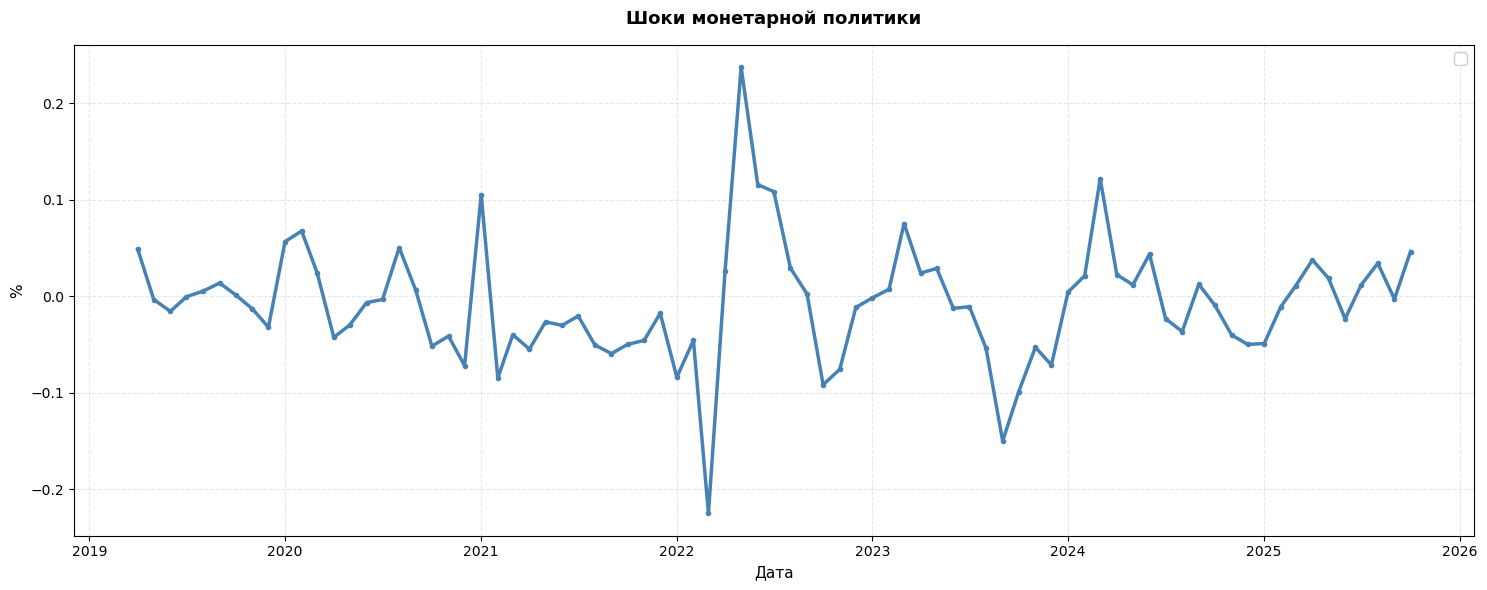


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ШОКИ МОНЕТАРНОЙ ПОЛИТИКИ
           Mon_Shock
Среднее    -0.007308
Медиана    -0.009178
Ст. откл.   0.061867
Мин.       -0.224779
Макс.       0.237499


In [236]:
###############################
# ВЫДЕЛЕНИЕ ШОКОВ МОНЕТАРНОЙ ПОЛИТИКИ
###############################
df_taylor['Taylor_Predicted'] = model9.fittedvalues
df_taylor['Mon_Shock'] = df_taylor['D_log_Nominal_Percent_Rate'] - df_taylor['Taylor_Predicted']

print("\n" + "="*60)
print("Визуализация шоков монетарной политики")
print("="*60)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_taylor['Date'], df_taylor['Mon_Shock'], 
         linewidth=2.5, color='steelblue', linestyle='-', marker='o', markersize=3)
ax1.set_title('Шоки монетарной политики', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('%', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ
###############################
# ИСПРАВЛЕНИЕ: descriptive_df это Series, работаем с ней как с Series
shock_series = df_taylor['Mon_Shock'].dropna()

desc_stats = {
    'Среднее': shock_series.mean(),
    'Медиана': shock_series.median(),
    'Ст. откл.': shock_series.std(),
    'Мин.': shock_series.min(),
    'Макс.': shock_series.max()
}

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ШОКИ МОНЕТАРНОЙ ПОЛИТИКИ")
print("="*60)

desc_df = pd.DataFrame(desc_stats, index=['Mon_Shock']).T
print(desc_df.round(6).to_string())

In [237]:
###############################
    #Тест на стационарность для шоков монетарной политики
###############################
variables_to_test = ['Mon_Shock']

df_test = df_taylor[variables_to_test]

stationarity_results = []
for var in variables_to_test:
    result = stationarity_tests(df_taylor[var], var)
    stationarity_results.append(result)

stationarity_df = pd.DataFrame(stationarity_results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ДЛЯ ШОКОВ")
print("="*60)
print(stationarity_df.to_string())


РЕЗУЛЬТАТЫ ТЕСТОВ ДЛЯ ШОКОВ
    Variable  ADF_Statistic   ADF_p_value  ADF_Critical_1%  ADF_Critical_5%  ADF_Critical_10%  ADF_Stationary  KPSS_Statistic  KPSS_p_value  KPSS_Critical_1%  KPSS_Critical_5%  KPSS_Critical_10%  KPSS_Stationary  DF_GLS_Statistic  DF_GLS_p_value  DF_GLS_Critical_1%  DF_GLS_Critical_5%  DF_GLS_Critical_10%  DF_GLS_Stationary
0  Mon_Shock      -5.689983  8.113084e-07        -3.517114        -2.899375         -2.586955            True        0.053837           0.1             0.739             0.463              0.347             True          -4.72405        0.000004            -2.80509           -2.184101            -1.873412               True


In [238]:
##############################
# Тест Фридмана на сезонность
##############################
variables_for_analysis = [
    ('Mon_Shock', 'Шоки монетарной политики')]
friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_taylor.columns:
        result = friedman_seasonality_test(df_taylor, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))


РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
Шоки монетарной политики    14.753846 0.194046            False        5        12



ЯДЕРНАЯ ОЦЕНКА ПЛОТНОСТИ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ МОДЕЛИ


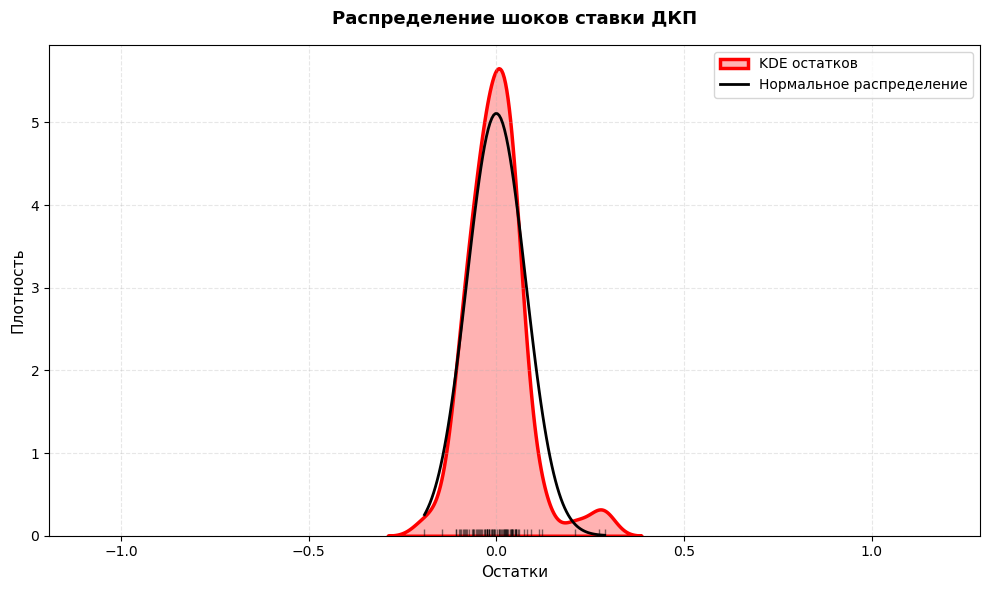


Параметры распределения:
  Среднее остатков: -0.000000
  Стд. отклонение: 0.078086
  Асимметрия (Skewness): 1.0940
  Эксцесс (Kurtosis): 3.2527
  N наблюдений: 79


In [239]:
###############################
# Ядерная оценка плотности распределения остатков
###############################
from scipy import stats
# Получаем остатки из лучшей модели
residuals = model9.resid

print("\n" + "="*80)
print("ЯДЕРНАЯ ОЦЕНКА ПЛОТНОСТИ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ МОДЕЛИ")
print("="*80)

fig, ax = plt.subplots(figsize=(10, 6))

# KDE + гистограмма
sns.kdeplot(residuals, fill=True, color='red', alpha=0.3, linewidth=2.5, label='KDE остатков')

# Нормальное распределение для сравнения
mu = residuals.mean()
sigma = residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
normal_dist = stats.norm.pdf(x, mu, sigma)
ax.plot(x, normal_dist, 'k-', linewidth=2, label='Нормальное распределение')

# Галочки остатков внизу оси X
for residual in residuals:
    ax.plot(residual, 0, '|', color='black', markersize=10, alpha=0.5)

ax.set_title('Распределение шоков ставки ДКП', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Остатки', fontsize=11)
ax.set_ylabel('Плотность', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(residuals.min() - 1, residuals.max() + 1)

plt.tight_layout()
plt.show()

print(f"\nПараметры распределения:")
print(f"  Среднее остатков: {residuals.mean():.6f}")
print(f"  Стд. отклонение: {residuals.std():.6f}")
print(f"  Асимметрия (Skewness): {stats.skew(residuals):.4f}")
print(f"  Эксцесс (Kurtosis): {stats.kurtosis(residuals):.4f}")
print(f"  N наблюдений: {len(residuals)}")


In [240]:
###############################
# Переходим к анализу панельных данных
###############################

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index() 

# Преобразуем Date
df_reg['Date'] = pd.to_datetime(df_reg['Date'])

# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============

df_shocks = df_taylor[['Date', 'Mon_Shock']].copy()
df_reg = df_reg.merge(df_shocks, on='Date', how='left')

df_exc = df_RF[['Date', 'exc_rate']].copy()
df_reg = df_reg.merge(df_exc, on='Date', how='left')

df_infl = df_RF[['Date', 'Inflation_Expectations']].copy()
df_reg = df_reg.merge(df_infl, on='Date', how='left')

df_bond = df_RF[['Date', 'Bonds_Rate_Correct_5Y']].copy()
df_reg = df_reg.merge(df_bond, on='Date', how='left')

# Переименование
df_reg.rename(columns={'exc_rate': 'Exc_rate'}, inplace=True)

# Создаем лаги
df_reg['Int_Rate_FL_lag1'] = df_reg.groupby('Region')['Int_Rate_FL'].shift(1)
df_reg['Int_Rate_Mort_lag1'] = df_reg.groupby('Region')['Int_Rate_Mort'].shift(1)
df_reg['Int_Rate_ConsCred_lag1'] = df_reg.groupby('Region')['Int_Rate_ConsCred'].shift(1)

# СПИСОК ПЕРЕМЕННЫХ
initial_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
   # 'New_Loans_Progr',
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y'
]

df_reg_analys = df_reg[['Region', 'Date'] + initial_vars].copy()
df_reg_analys = df_reg_analys[df_reg['Region'] != 'Москва']
df_reg_analys = df_reg_analys.dropna()

In [241]:
df_reg_analys.head()

,Region,Date,Int_Rate_FL,Int_Rate_FL_lag1,Int_Rate_Mort,Credit_impulse,Int_Rate_Mort_lag1,Int_Rate_ConsCred,Int_Rate_ConsCred_lag1,Cred_nagr,...,Def_Zadolg_Fl,Def_Zadolg_Mort,Def_Zadolg_ConsCred,New_Loans_Fl,New_Loans_Mort,New_Loans_ConsCred,Mon_Shock,Exc_rate,Inflation_Expectations,Bonds_Rate_Correct_5Y
2,Белгородская область,2019-04-01,13.988365,13.764491,10.431156,1.734442,10.119091,15.022465,15.090566,0.336535,...,4.921246,0.771662,7.140479,9.938011e+06,1.535489e+06,8.402522e+06,0.049088,64.603105,9.004132,0.316818
3,Белгородская область,2019-05-01,13.975779,13.988365,10.629171,2.897391,10.431156,14.943737,15.022465,0.341271,...,4.889117,0.768352,7.078234,1.042482e+07,1.654725e+06,8.770090e+06,-0.003213,64.818706,9.416996,0.295714
4,Белгородская область,2019-06-01,14.197338,13.975779,10.697008,2.214858,10.629171,15.138499,14.943737,0.342186,...,4.866700,0.771485,7.024847,9.595191e+06,1.375143e+06,8.220047e+06,-0.015468,64.169050,9.280142,0.197895
5,Белгородская область,2019-07-01,13.855339,14.197338,10.354990,0.904920,10.697008,14.936965,15.138499,0.343333,...,4.711675,0.666549,6.835300,9.632884e+06,1.541998e+06,8.090886e+06,-0.000333,63.222682,9.344961,0.210870
6,Белгородская область,2019-08-01,13.853486,13.855339,10.204734,1.584402,10.354990,14.889971,14.936965,0.345571,...,4.730897,0.668930,6.823429,1.029429e+07,1.560400e+06,8.733891e+06,0.005457,65.587483,9.304511,0.270000


In [242]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6545 entries, 2 to 6882
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Region                  6545 non-null   object        
 1   Date                    6545 non-null   datetime64[ns]
 2   Int_Rate_FL             6545 non-null   float64       
 3   Int_Rate_FL_lag1        6545 non-null   float64       
 4   Int_Rate_Mort           6545 non-null   float64       
 5   Credit_impulse          6545 non-null   float64       
 6   Int_Rate_Mort_lag1      6545 non-null   float64       
 7   Int_Rate_ConsCred       6545 non-null   float64       
 8   Int_Rate_ConsCred_lag1  6545 non-null   float64       
 9   Cred_nagr               6545 non-null   float64       
 10  D_top5_rozn             6545 non-null   float64       
 11  Fin_Dostup              6545 non-null   float64       
 12  Cred_structure          6545 non-null   float64      

In [243]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
   # 'New_Loans_Progr',
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y'
]

def detect_outlier_regions_iqr(df, key_vars, min_obs=60, max_na_pct=0.3):
    """
    Определение выбросов по IQR (межквартильный размах)
    """
    region_stats = []
    
    for region in df['Region'].unique():
        reg_data = df[df['Region'] == region][key_vars].dropna()
        
        # 1. Минимум наблюдений
        n_obs = len(reg_data)
        if n_obs < min_obs:
            region_stats.append({
                'Region': region,
                'N_obs': n_obs,
                'Reason': f'Мало данных (<{min_obs})',
                'Status': 'EXCLUDE'
            })
            continue
        
        # 2. % пропусков
        total_rows = len(df[df['Region'] == region])
        na_pct = 1 - (n_obs / total_rows)
        if na_pct > max_na_pct:
            region_stats.append({
                'Region': region,
                'N_obs': n_obs,
                'NA_pct': f'{na_pct:.1%}',
                'Reason': f'Много пропусков (>{max_na_pct*100}%)',
                'Status': 'EXCLUDE'
            })
            continue
        
        # 3. IQR по переменным
        iqr_outliers = []
        for col in key_vars:
            if col in reg_data.columns:
                data = reg_data[col].dropna()
                if len(data) > 0:
                    Q1 = data.quantile(0.15)
                    Q3 = data.quantile(0.85)
                    IQR = Q3 - Q1
                    lower_bound = Q1 - 1.5 * IQR
                    upper_bound = Q3 + 1.5 * IQR
                    outliers = ((data < lower_bound) | (data > upper_bound)).sum()
                    iqr_outliers.append(outliers)
        
        iqr_total = sum(iqr_outliers)
        iqr_pct = iqr_total / n_obs if n_obs > 0 else 0

        
        # РЕШЕНИЕ
        status = 'KEEP'
        reasons = []
        
        if iqr_pct > 0.2:  # >20% выбросов по IQR
            reasons.append(f'Много выбросов по IQR ({iqr_pct:.1%})')
            status = 'EXCLUDE'
        
        region_stats.append({
            'Region': region,
            'N_obs': n_obs,
            'NA_pct': f'{na_pct:.1%}',
            'IQR_outliers': iqr_total,
            'IQR_pct': f'{iqr_pct:.1%}',
            'Reasons': '; '.join(reasons),
            'Status': status
        })
    
    return pd.DataFrame(region_stats)

# АНАЛИЗ РЕГИОНОВ ПО IQR
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys= df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_analys.shape}")





ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 85 РЕГИОНОВ (IQR)
                                              Region  N_obs NA_pct  IQR_outliers IQR_pct                       Reasons  Status
                                Белгородская область     77   0.0%             4    5.2%                                  KEEP
                                    Брянская область     77   0.0%             4    5.2%                                  KEEP
                                Владимирская область     77   0.0%             4    5.2%                                  KEEP
                                 Воронежская область     77   0.0%             4    5.2%                                  KEEP
                                  Ивановская область     77   0.0%             3    3.9%                                  KEEP
                                    Тверская область     77   0.0%             3    3.9%                                  KEEP
                                   Калужская область

In [244]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
descriptive_df = df_reg_analys[[
    'Int_Rate_FL',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_ConsCred',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    #'New_Loans_Progr',
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y'      
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                             Среднее       Медиана     ст. откл.        Мин.  \
Int_Rate_FL             1.426000e+01  1.315400e+01  3.484000e+00       9.100   
Int_Rate_Mort           8.256000e+00  8.069000e+00  1.300000e+00       3.327   
Credit_impulse         -6.370000e-01 -1.270000e-01  6.558000e+00     -59.204   
Int_Rate_ConsCred       1.806700e+01  1.592800e+01  5.660000e+00       1.306   
Cred_nagr               3.540000e-01  3.580000e-01  8.500000e-02       0.072   
D_top5_rozn             7.830000e-01  7.800000e-01  6.300000e-02       0.614   
Fin_Dostup              1.919000e+01  1.862200e+01  6.043000e+00       2.972   
Cred_structure          4.680000e-01  4.710000e-01  6.500000e-02       0.151   
Def_Zadolg_Fl           4.241000e+00  4.190000e+00  1.117000e+00       1.407   
Def_Zadolg_Mort         6.140000e-01  4.720000e-01  5.120000e-01       0.043   
Def_Zadolg_ConsCred     7.446000e+00  7.447000e+00  1.556000e+00   

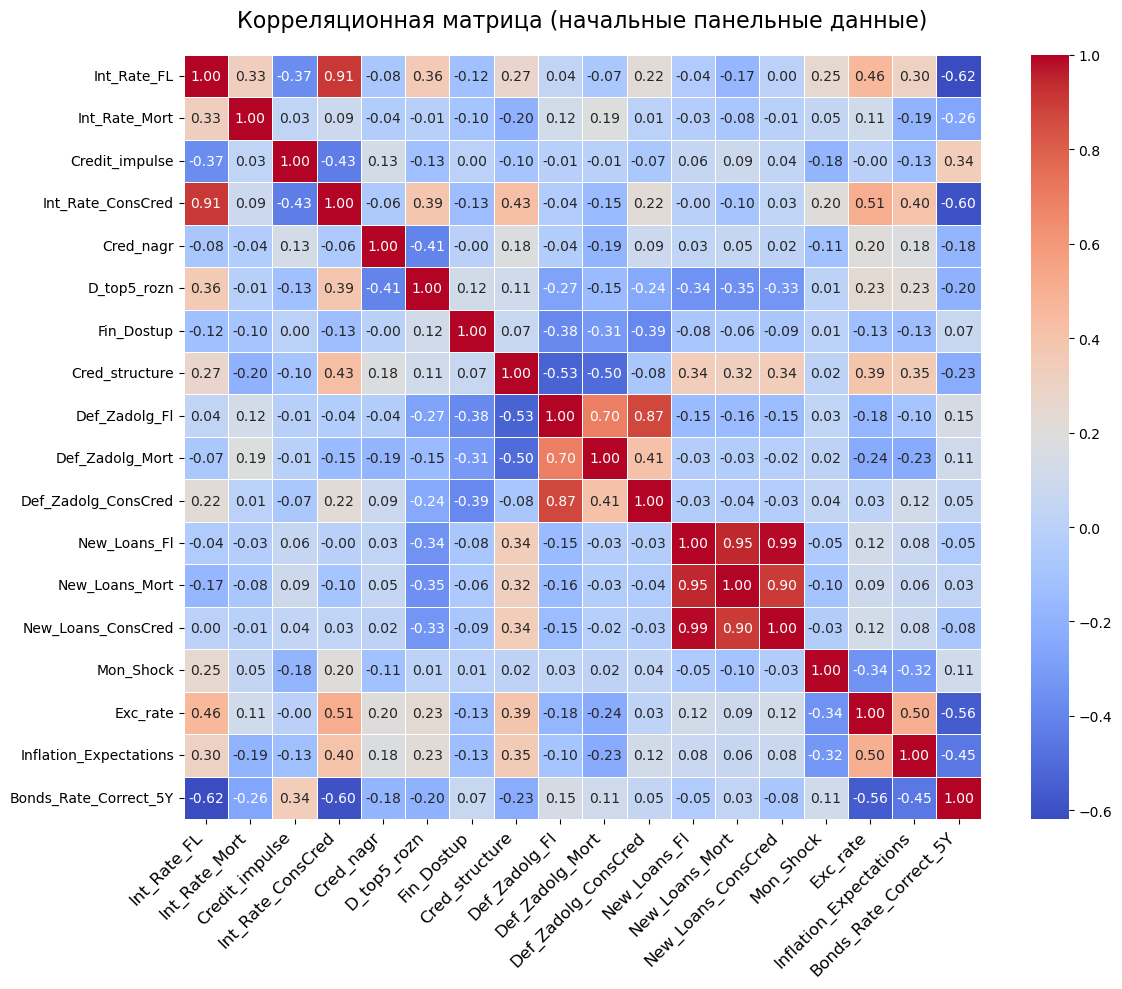

In [245]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные панельные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [246]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 1
###############################

vif_variables = [
    'Int_Rate_FL_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Fl',
    #'New_Loans_Progr',
    'Mon_Shock',
    'New_Loans_Fl',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations'
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1
              Variable      VIF
      Int_Rate_FL_lag1 2.614815
 Bonds_Rate_Correct_5Y 2.477500
              Exc_rate 2.328233
        Cred_structure 2.265123
           D_top5_rozn 2.252934
         Def_Zadolg_Fl 2.173806
Inflation_Expectations 1.739355
             Cred_nagr 1.736755
          New_Loans_Fl 1.560157
             Mon_Shock 1.556503
        Credit_impulse 1.361779
            Fin_Dostup 1.273889


In [247]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 2
###############################

vif_variables = [
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_ConsCred',
    #'New_Loans_Progr',
    'Mon_Shock',
    'New_Loans_ConsCred',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations'
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2
              Variable      VIF
Int_Rate_ConsCred_lag1 3.334871
 Bonds_Rate_Correct_5Y 2.364249
              Exc_rate 2.323778
           D_top5_rozn 2.304767
        Cred_structure 1.856021
Inflation_Expectations 1.761764
             Cred_nagr 1.742941
   Def_Zadolg_ConsCred 1.688604
             Mon_Shock 1.614085
    New_Loans_ConsCred 1.552764
        Credit_impulse 1.415141
            Fin_Dostup 1.247934


In [248]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 3
###############################

vif_variables = [
    'Int_Rate_Mort_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Mort',
    #'New_Loans_Progr',
    'New_Loans_Mort',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'Exc_rate',
    'Inflation_Expectations'
]
 
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3
              Variable      VIF
 Bonds_Rate_Correct_5Y 2.219844
              Exc_rate 2.195520
        Cred_structure 1.949192
           D_top5_rozn 1.948291
Inflation_Expectations 1.902709
             Cred_nagr 1.648279
       Def_Zadolg_Mort 1.600091
        New_Loans_Mort 1.500865
    Int_Rate_Mort_lag1 1.415721
             Mon_Shock 1.360730
        Credit_impulse 1.335026
            Fin_Dostup 1.237361



СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ

Курс рубля (Exc_rate):
  ✓ Успешно скорректировано, снижение волатильности: 1.7%

Инфляционные ожидания (Inflation_Expectations):
  ✓ Успешно скорректировано, снижение волатильности: 1.8%

Ставки на облигации скорректированные 5Y (Bonds_Rate_Correct_5Y):
  ✓ Успешно скорректировано, снижение волатильности: 2.5%

СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ

Ставка на кредиты ФЛ (Int_Rate_FL):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 79/79 регионов

Ставка на кредиты ФЛ лаг (Int_Rate_FL_lag1):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 79/79 регионов

Ставка на ипотеку (Int_Rate_Mort):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 79/79 регионов

Ставка на ипотеку лаг (Int_Rate_Mort_lag1):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 79/79 регионов

Кредитный импульс (Credit_impulse):
  Обрабатываю 79 регионов...
  ✓ Успешно скорректировано 77/79 регионов

Ставка на потребительский кре

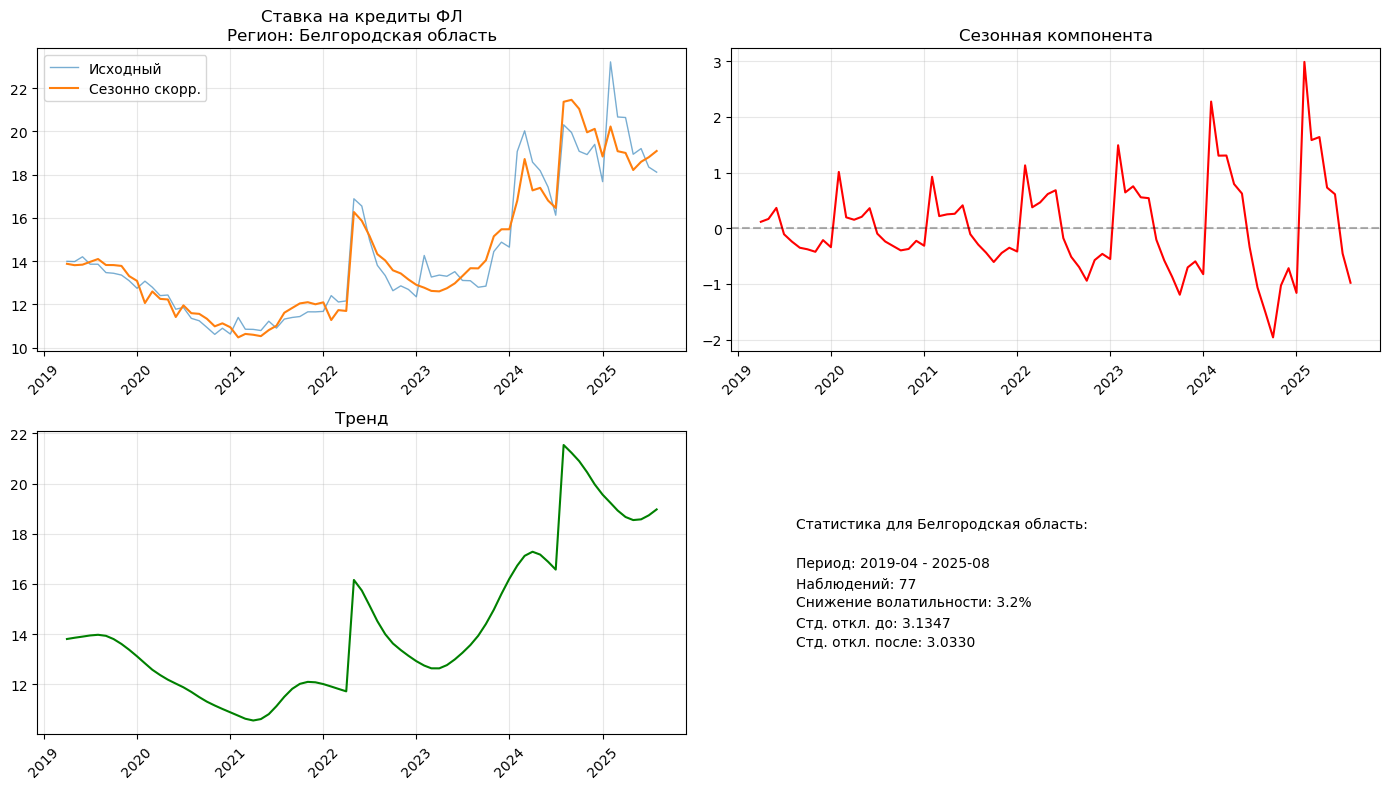

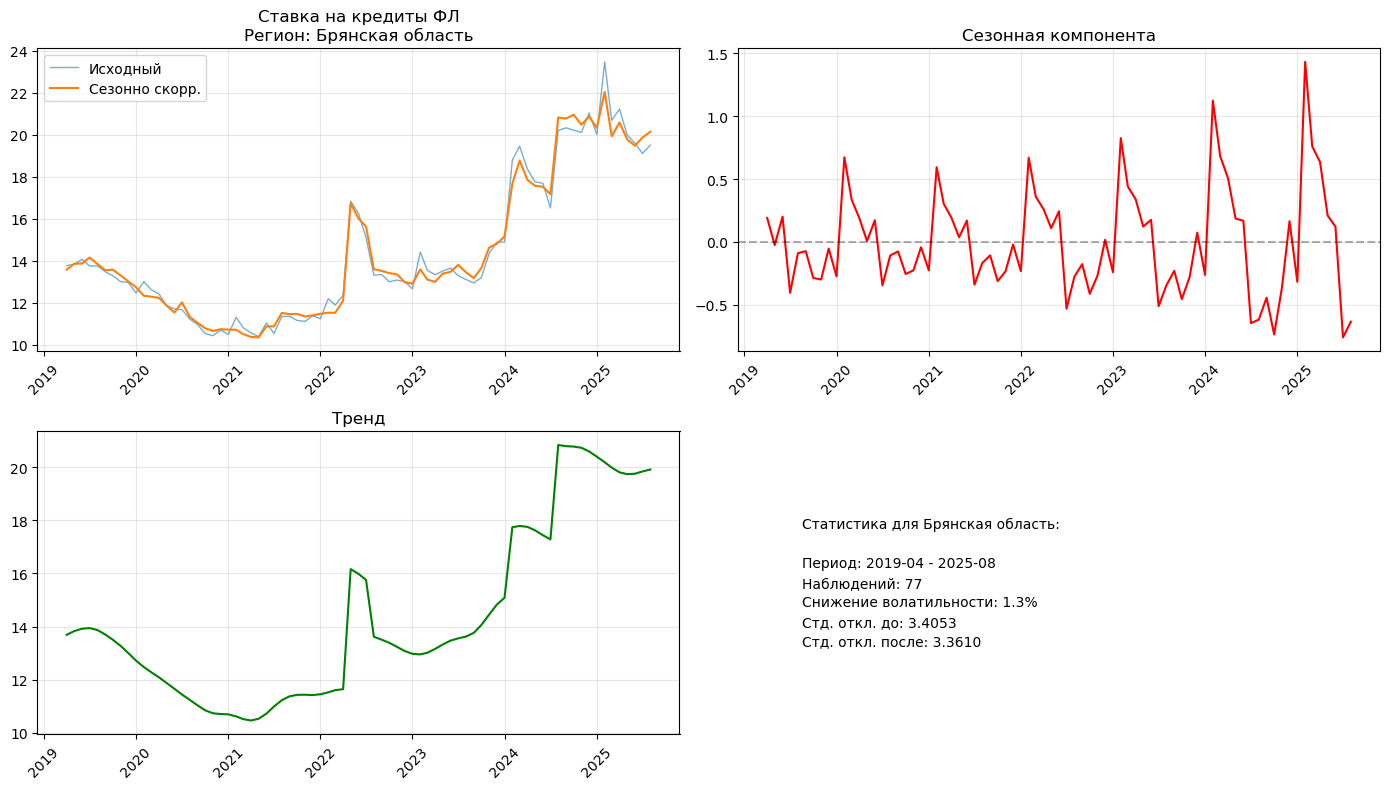

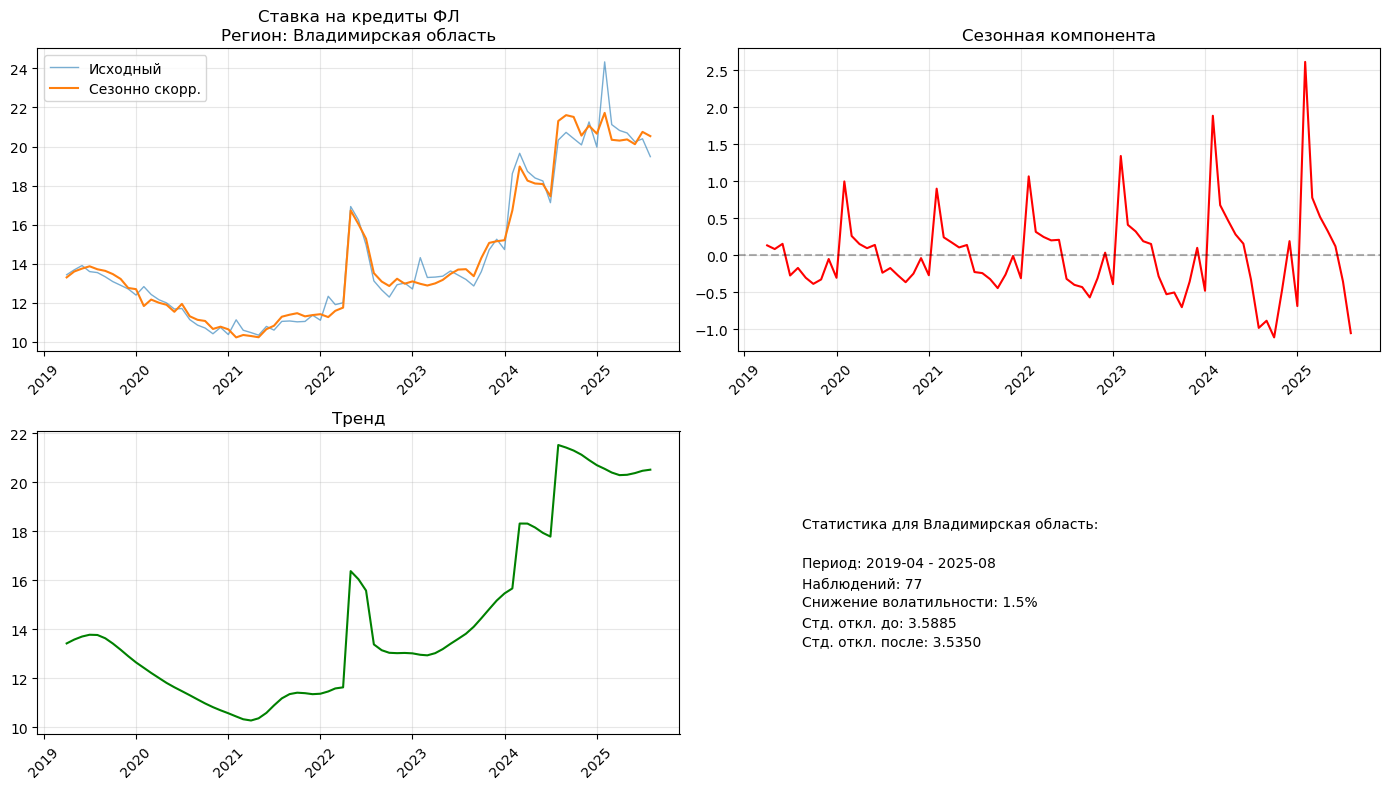

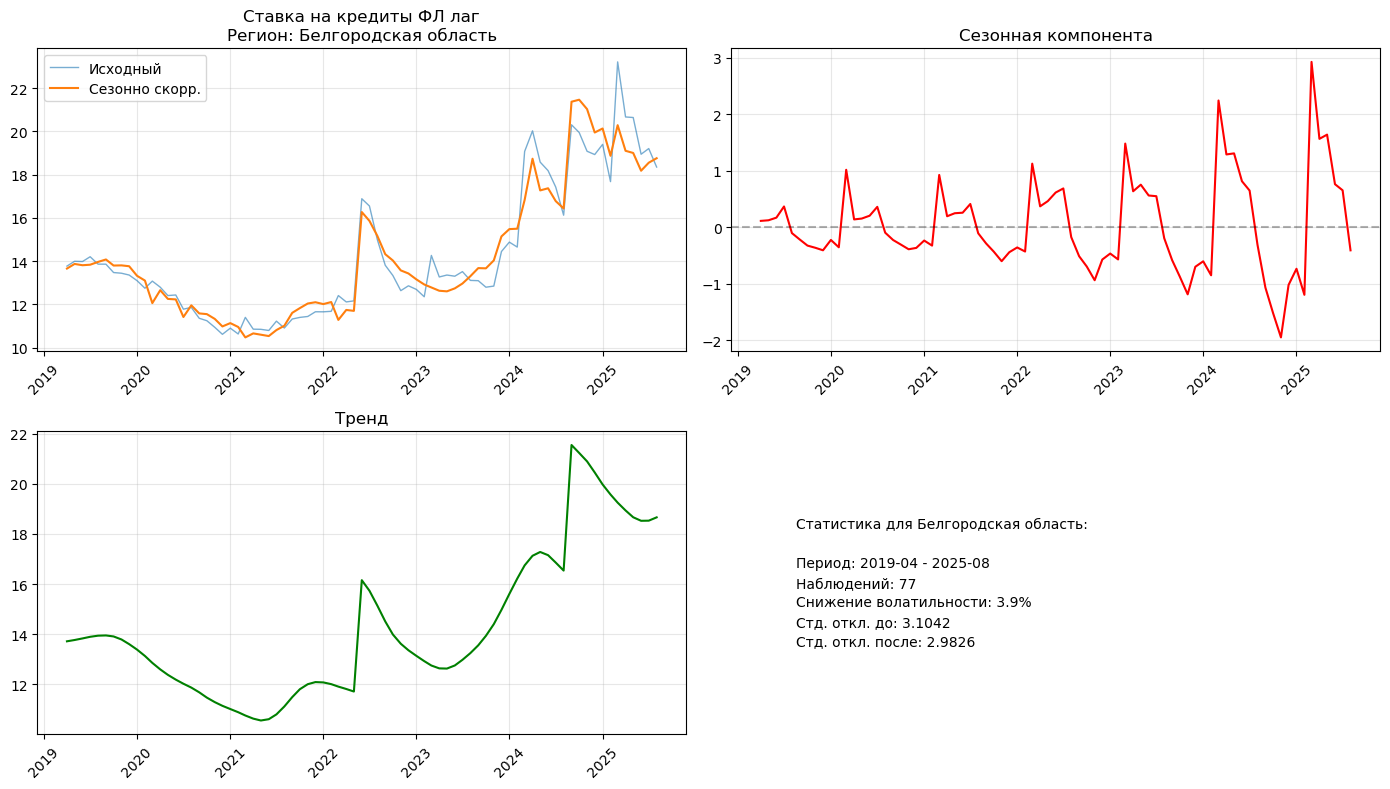

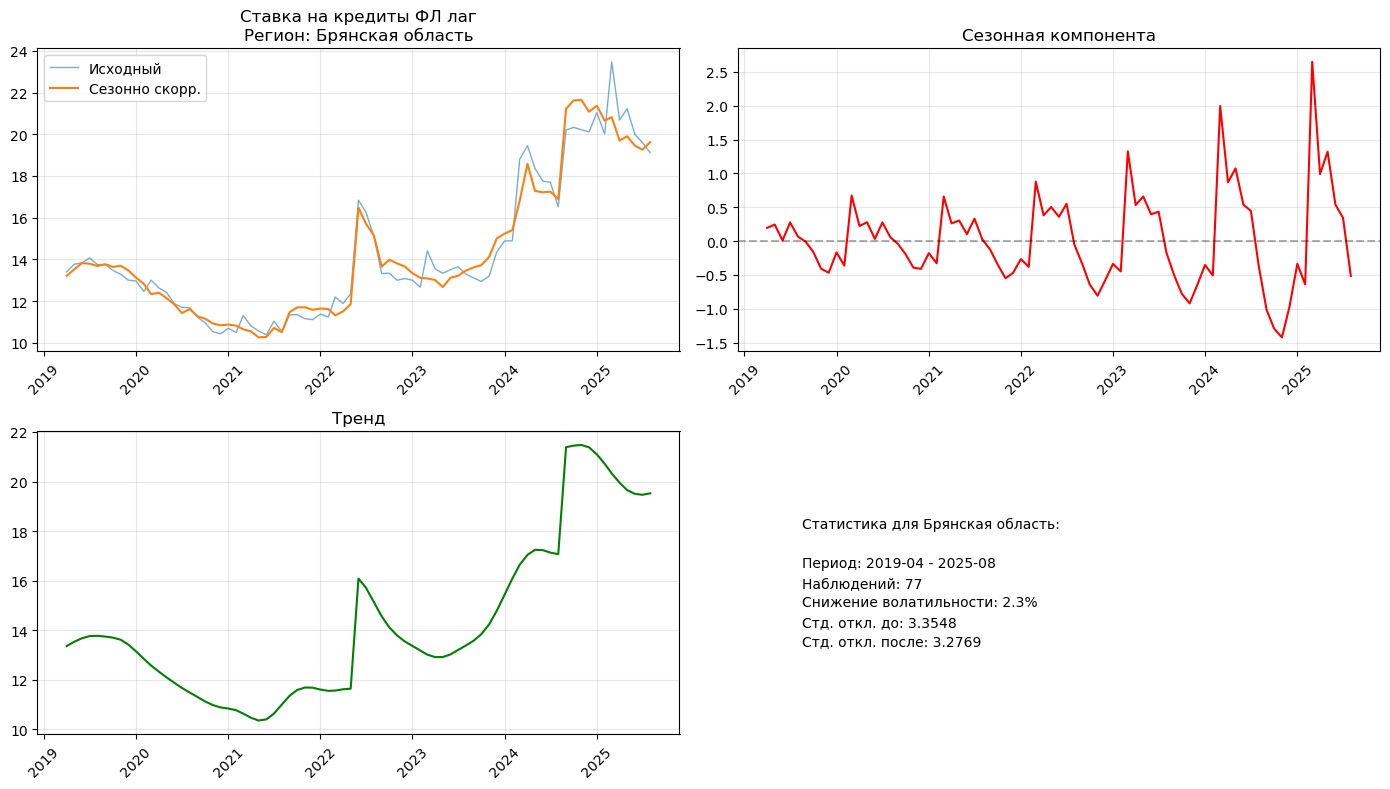

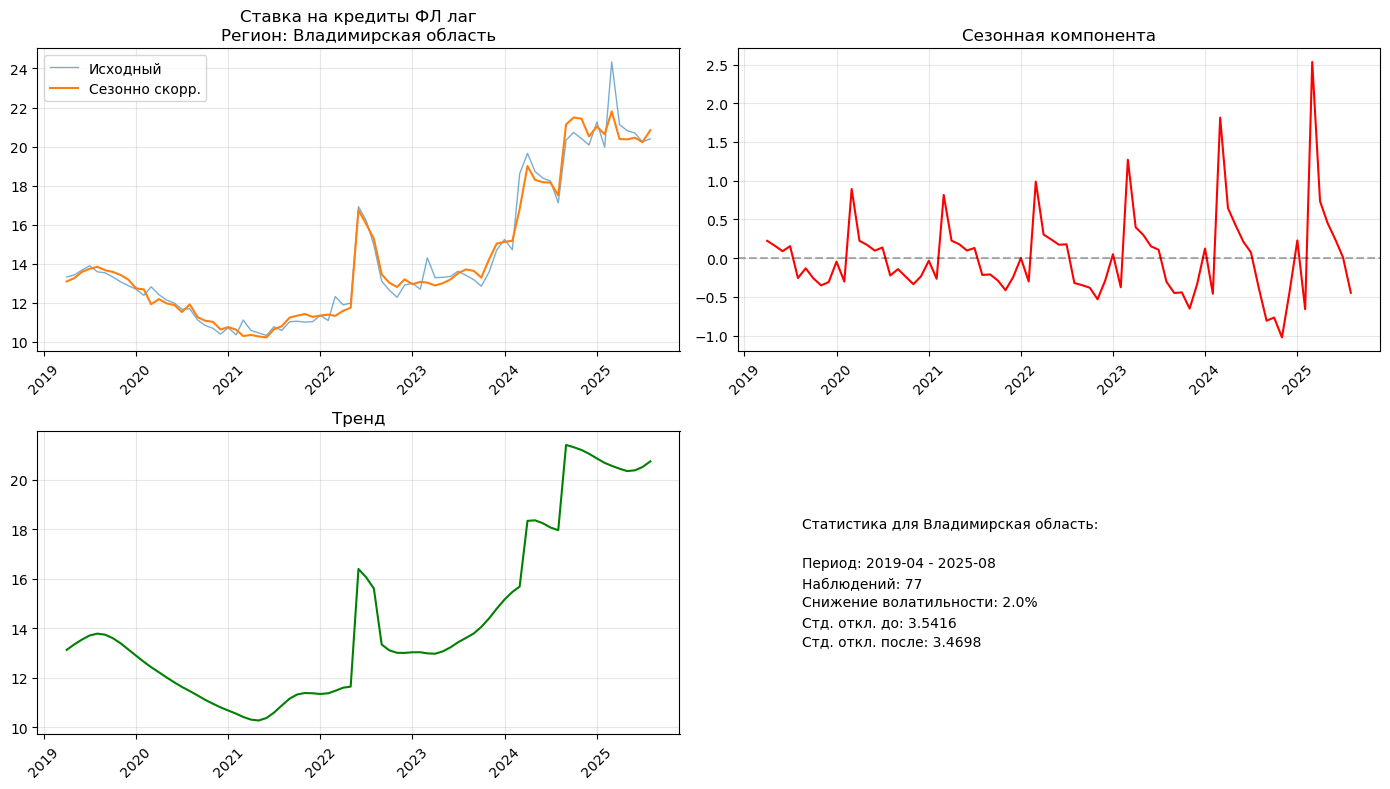


Графики федеральных переменных...


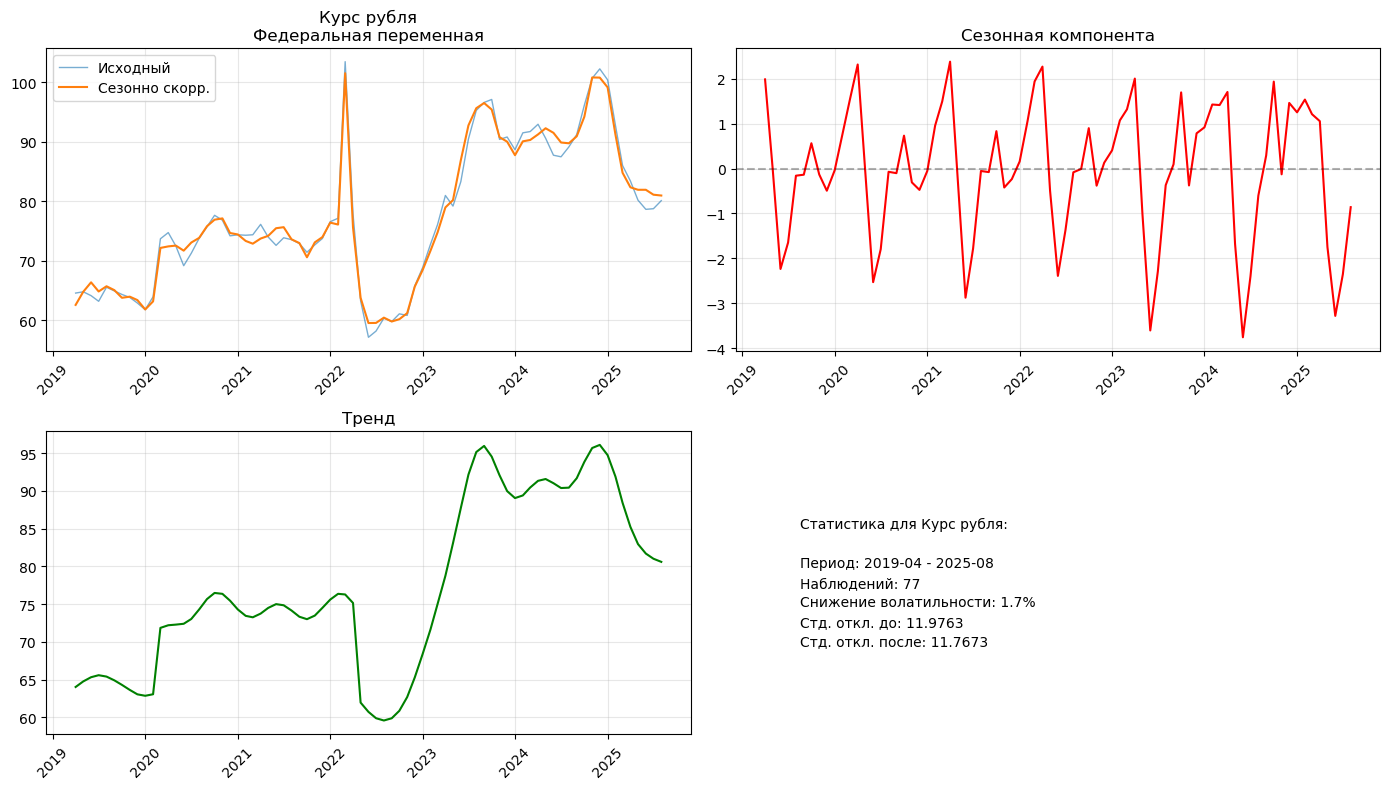

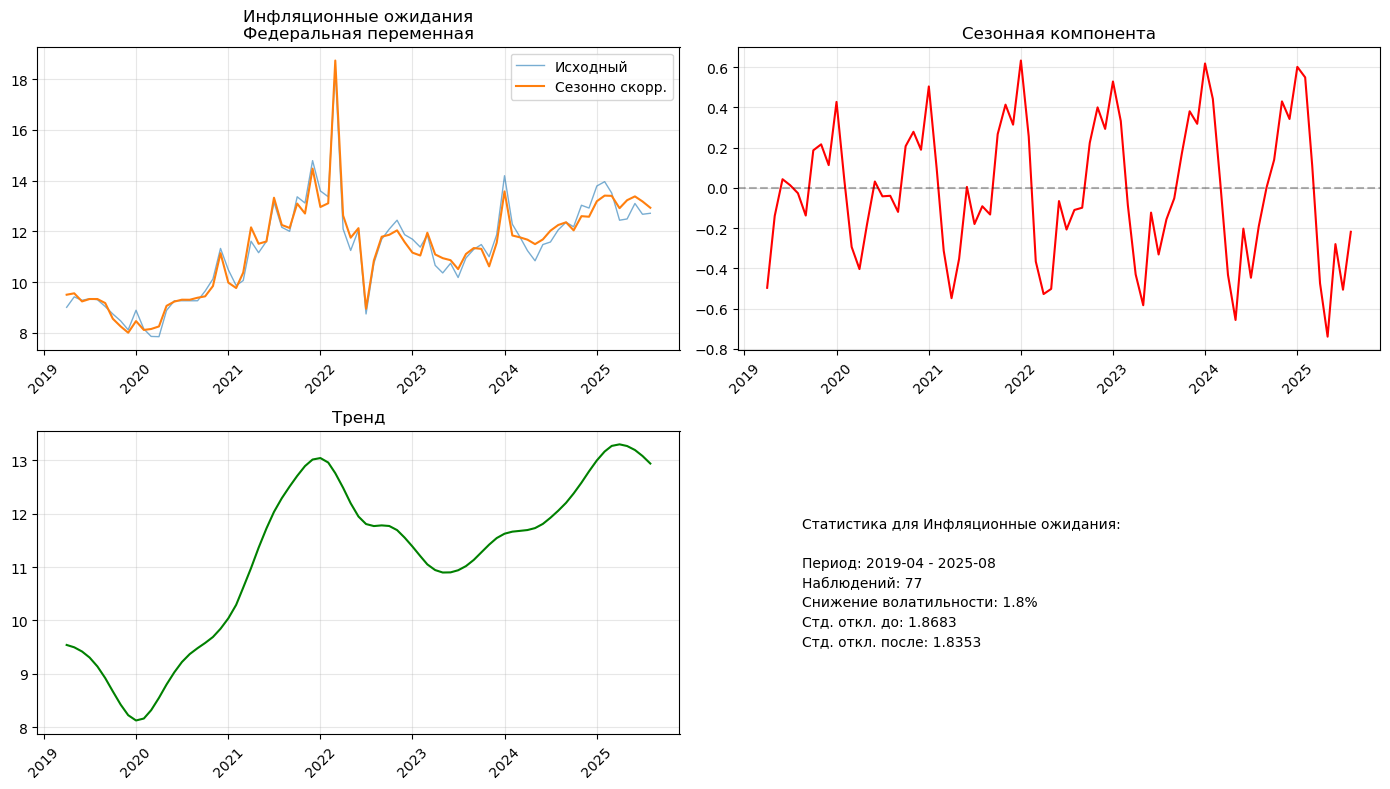

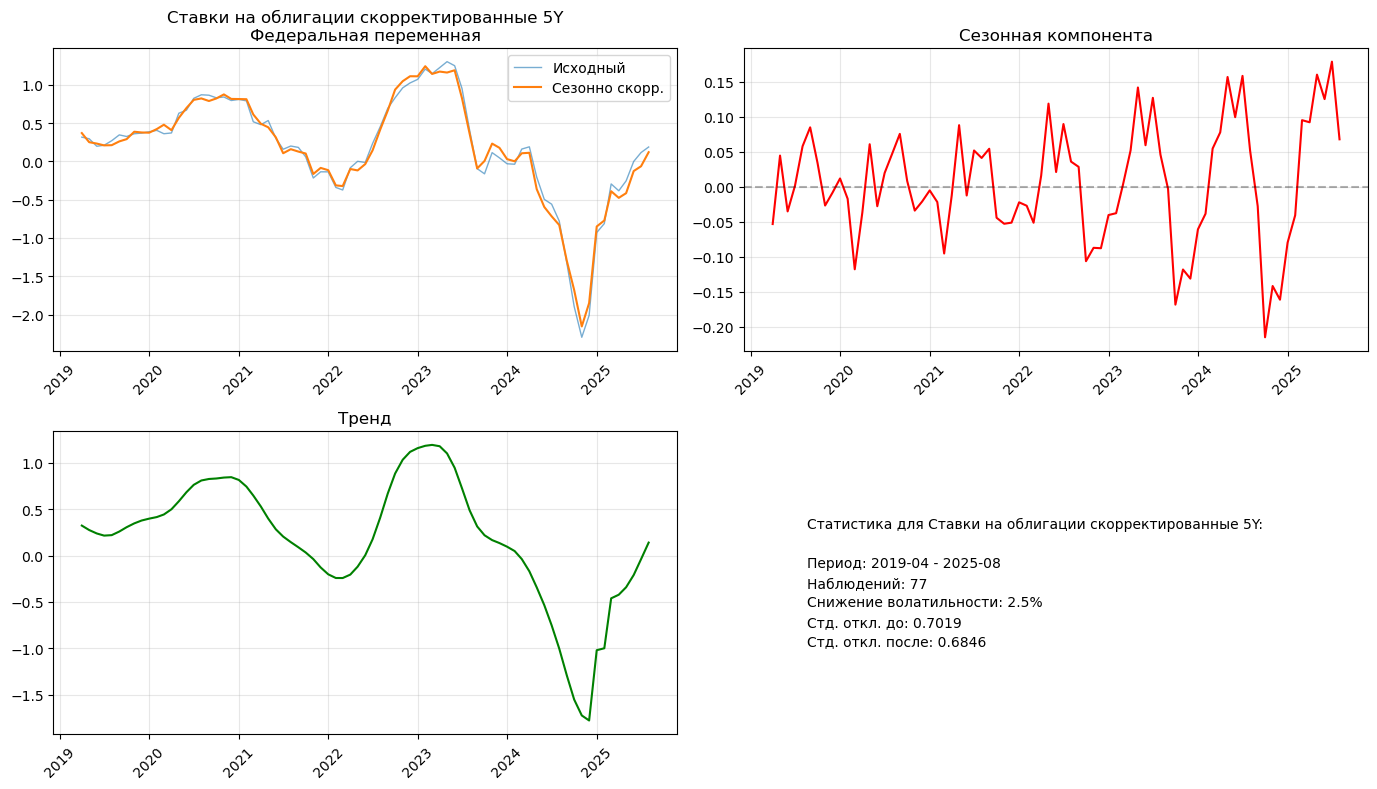


ФИНАЛЬНАЯ СТАТИСТИКА

Обработано федеральных переменных: 3/3
Обработано региональных переменных: 17/17
Общее количество добавленных столбцов: 60
Форма df_reg_analys: (6083, 83)

Столбцов _adj: 20
Столбцов _trend: 20
Столбцов _seasonal: 20

✓ Скорректированные ряды добавлены в df_reg_analys
✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)


In [249]:
# ===== СЕЗОННАЯ КОРРЕКТИРОВКА ДЛЯ ПАНЕЛЬНЫХ ДАННЫХ =====


from statsmodels.tsa.x13 import x13_arima_analysis
import tempfile
import uuid

# Заглушаем предупреждения
warnings.filterwarnings('ignore')

# Путь к бинарнику X-13
X13_PATH = 'C:\\Program Files (x86)\\x13as'

# Проверка, что бинарник доступен
if not os.path.exists(X13_PATH):
    raise FileNotFoundError(f"X-13 binary not found at {X13_PATH}")

# Если X13_PATH — полный путь к бинарнику, берем его директорию для x12path
x13_dir = X13_PATH if os.path.isdir(X13_PATH) else os.path.dirname(X13_PATH)

# Создаем папку для логов
os.makedirs("x13_logs", exist_ok=True)

# ============ ОПРЕДЕЛЕНИЕ ПЕРЕМЕННЫХ ДЛЯ КОРРЕКТИРОВКИ ============

# ФЕДЕРАЛЬНЫЕ переменные (одна серия для всех регионов)
federal_variables = {
    'Exc_rate': 'Курс рубля', 
    'Inflation_Expectations': 'Инфляционные ожидания',
    'Bonds_Rate_Correct_5Y': 'Ставки на облигации скорректированные 5Y'
}

# РЕГИОНАЛЬНЫЕ переменные (серии по каждому региону)
regional_variables = {
    'Int_Rate_FL': 'Ставка на кредиты ФЛ',
    'Int_Rate_FL_lag1' : 'Ставка на кредиты ФЛ лаг',
    'Int_Rate_Mort': 'Ставка на ипотеку',
    'Int_Rate_Mort_lag1': 'Ставка на ипотеку лаг',
    'Credit_impulse': 'Кредитный импульс',
    'Int_Rate_ConsCred': 'Ставка на потребительский кредит',
    'Int_Rate_ConsCred_lag1': 'Ставка на потребительский кредит лаг',
    'Cred_nagr': 'Кредитная нагрузка',
    'D_top5_rozn': 'Доля топ-5 банков в розничном портфеле региона',
    'Fin_Dostup':'Кол-во пунктов банковского обслуживания на 100к чел.',
    'Cred_structure':'Доля ипотечных жилищных кредитов в розничном портфеле',
    'Def_Zadolg_Fl':'Доля просроченной задолженности по кредитам физических лиц',
    'Def_Zadolg_Mort':'Доля просроченной задолженности по ипотечным жилищным кредитам',
    'Def_Zadolg_ConsCred':'Доля просроченной задолженности по потребительским кредитам',
    'New_Loans_Fl': 'Новые кредиты ФЛ',
    'New_Loans_Mort': 'Новые кредиты ипотека',
    'New_Loans_ConsCred': 'Новые кредиты потребит.',
    
}
# ============ ФУНКЦИЯ ДЛЯ СЕЗОННОЙ КОРРЕКТИРОВКИ ОДНОЙ СЕРИИ ============

def seasonal_adjust_panel_series(series_data, variable_name, region_name=None, min_obs=24):
    """
    Выполнить X-13 сезонную корректировку для одной серии (панельные данные)
    
    Parameters:
    -----------
    series_data : pd.Series
        Временной ряд с DatetimeIndex
    variable_name : str
        Название переменной
    region_name : str, optional
        Название региона (для региональных переменных)
    min_obs : int
        Minimum number of observations
    
    Returns:
    --------
    dict с результатами или None при ошибке
    """
    try:
        # Проверка данных
        if len(series_data) < min_obs:
            return None
        
        # Убедиться, что индекс - DatetimeIndex
        if not isinstance(series_data.index, pd.DatetimeIndex):
            series_data.index = pd.to_datetime(series_data.index)
        
        # Установить частоту на месячную
        ts_regular = series_data.asfreq('MS').dropna()
        
        if len(ts_regular) < min_obs:
            return None
        
        # Информация о данных
        start_date = ts_regular.index[0]
        end_date = ts_regular.index[-1]
        
        # Создаем уникальную временную папку для каждого вызова X-13
        # чтобы избежать конфликтов файлов
        temp_dir = tempfile.mkdtemp(prefix=f"x13_{uuid.uuid4().hex[:8]}_")
        
        # Запуск X-13 с указанием уникальной временной директории
        try:
            res = x13_arima_analysis(
                endog=ts_regular,
                x12path=x13_dir,
                prefer_x13=True,
                outlier=True,
                trading=False,
                print_stdout=False
            )
            
            # Извлечение компонент
            adj = res.seasadj
            trend = res.trend
            seas = ts_regular - adj
            
        except Exception as e:
            # Если X-13 не сработал, попробуем без outlier
            try:
                res = x13_arima_analysis(
                    endog=ts_regular,
                    x12path=x13_dir,
                    prefer_x13=True,
                    outlier=False,  # Без определения выбросов
                    trading=False,
                    print_stdout=False
                )
                
                adj = res.seasadj
                trend = res.trend
                seas = ts_regular - adj
                
            except Exception as e2:
                # Если все еще не работает, пропускаем
                return None
        
        # Расчёт эффективности
        original_std = ts_regular.std()
        adj_std = adj.std()
        reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0
        
        # Удаляем временную директорию
        try:
            import shutil
            shutil.rmtree(temp_dir, ignore_errors=True)
        except:
            pass
        
        return {
            'dates': ts_regular.index,
            'adj': adj.values,
            'trend': trend.values,
            'seasonal': seas.values,
            'reduction': reduction
        }
        
    except Exception as e:
        # Подавляем вывод ошибок
        return None

# ============ ОБРАБОТКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ ============

print("\n" + "="*70)
print("СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ")
print("="*70)

federal_adjusted = {}

for col, name in federal_variables.items():
    if col not in df_reg_analys.columns:
        print(f"\n⚠️  {name} ({col}): столбец не найден. Пропуск.")
        continue
    
    print(f"\n{name} ({col}):")
    
    # Для федеральных переменных берем уникальные значения по датам
    fed_data = df_reg_analys[['Date', col]].copy().dropna()
    
    if len(fed_data) == 0:
        print(f"  ✗ Нет данных. Пропуск.")
        continue
    
    # Убедиться, что одно значение на дату
    fed_data = fed_data.drop_duplicates('Date')
    fed_data = fed_data.set_index('Date')[col].sort_index()
    
    # Сезонная корректировка
    result = seasonal_adjust_panel_series(fed_data, col, region_name=None)
    
    if result is not None:
        federal_adjusted[col] = result
        print(f"  ✓ Успешно скорректировано, снижение волатильности: {result['reduction']:.1f}%")
        
        # Добавляем результаты обратно в df_reg_analys
        for date, adj_val, trend_val, seas_val in zip(
            result['dates'], result['adj'], result['trend'], result['seasonal']
        ):
            mask = df_reg_analys['Date'] == date
            df_reg_analys.loc[mask, f'{col}_adj'] = adj_val
            df_reg_analys.loc[mask, f'{col}_trend'] = trend_val
            df_reg_analys.loc[mask, f'{col}_seasonal'] = seas_val
    else:
        print(f"  ✗ Не удалось скорректировать")

# ============ ОБРАБОТКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ ============

print("\n" + "="*70)
print("СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ")
print("="*70)

regional_adjusted = {}

for col, name in regional_variables.items():
    if col not in df_reg_analys.columns:
        print(f"\n⚠️  {name} ({col}): столбец не найден. Пропуск.")
        continue
    
    print(f"\n{name} ({col}):")
    
    # Получаем список регионов
    regions = df_reg_analys['Region'].unique()
    print(f"  Обрабатываю {len(regions)} регионов...")
    
    regional_adjusted[col] = {}
    successful_regions = 0
    
    for region in regions:
        # Фильтруем данные по региону
        region_data = df_reg_analys[df_reg_analys['Region'] == region][['Date', col]].copy().dropna()
        
        if len(region_data) < 24:
            continue  # Пропускаем регионы с недостаточным количеством данных
        
        # Подготавливаем временной ряд
        region_series = region_data.set_index('Date')[col].sort_index()
        
        # Сезонная корректировка
        result = seasonal_adjust_panel_series(region_series, col, region_name=region, min_obs=24)
        
        if result is not None:
            regional_adjusted[col][region] = result
            successful_regions += 1
            
            # Добавляем результаты в df_reg_analys
            for date, adj_val, trend_val, seas_val in zip(
                result['dates'], result['adj'], result['trend'], result['seasonal']
            ):
                mask = (df_reg_analys['Region'] == region) & (df_reg_analys['Date'] == date)
                if mask.any():
                    df_reg_analys.loc[mask, f'{col}_adj'] = adj_val
                    df_reg_analys.loc[mask, f'{col}_trend'] = trend_val
                    df_reg_analys.loc[mask, f'{col}_seasonal'] = seas_val
    
    print(f"  ✓ Успешно скорректировано {successful_regions}/{len(regions)} регионов")

# ============ ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ ============

print("\n" + "="*70)
print("ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ")
print("="*70)

all_variables = list(regional_variables.keys()) + list(federal_variables.keys())
added_columns = []

for col in all_variables:
    for suffix in ['_adj', '_trend', '_seasonal']:
        new_col = f'{col}{suffix}'
        if new_col in df_reg_analys.columns:
            added_columns.append(new_col)
            non_na_count = df_reg_analys[new_col].notna().sum()
            print(f"✓ {new_col}: {non_na_count} не-NaN значений")

print(f"\n✓ Всего добавлено столбцов: {len(added_columns)}")

# ============ СВОДКА РЕЗУЛЬТАТОВ ============

print("\n" + "="*70)
print("СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКТИРОВКИ")
print("="*70)

# Федеральные переменные
print("\nФедеральные переменные:")
print("-" * 50)
print(f"{'Переменная':<30} {'Волатильность ↓':<15}")
print("-" * 50)

for col in federal_variables:
    adj_col = f'{col}_adj'
    if adj_col in df_reg_analys.columns and col in federal_adjusted:
        reduction = federal_adjusted[col]['reduction']
        print(f"{federal_variables[col]:<30} {reduction:>14.1f}%")

# Региональные переменные (среднее по регионам)
print("\n\nРегиональные переменные (среднее по регионам):")
print("-" * 50)
print(f"{'Переменная':<30} {'Волатильность ↓':<15}")
print("-" * 50)

for col in regional_variables:
    adj_col = f'{col}_adj'
    if adj_col in df_reg_analys.columns and col in regional_adjusted:
        # Рассчитываем среднее снижение волатильности
        reductions = []
        for region_data in regional_adjusted[col].values():
            reductions.append(region_data['reduction'])
        
        if reductions:
            avg_reduction = np.mean(reductions)
            print(f"{regional_variables[col]:<30} {avg_reduction:>14.1f}%")

# ============ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ============

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (ПРИМЕРЫ)")
print("="*70)

# Выбираем несколько регионов для визуализации
sample_regions = df_reg_analys['Region'].unique()[:3]  # Первые 3 региона

# Визуализация для нескольких переменных
for col in list(regional_variables.keys())[:2]:  # Первые 2 региональные переменные
    adj_col = f'{col}_adj'
    
    if adj_col not in df_reg_analys.columns:
        continue
    
    for region in sample_regions:
        # Фильтруем данные для региона
        region_mask = (df_reg_analys['Region'] == region) & df_reg_analys[adj_col].notna()
        region_data = df_reg_analys[region_mask]
        
        if len(region_data) == 0:
            continue
        
        # Создаем график
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        
        # График 1: Исходный vs скорректированный
        ax = axes[0, 0]
        dates = region_data['Date']
        ax.plot(dates, region_data[col], label='Исходный', alpha=0.6, linewidth=1)
        ax.plot(dates, region_data[adj_col], label='Сезонно скорр.', linewidth=1.5)
        ax.set_title(f'{regional_variables[col]}\nРегион: {region}')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # График 2: Сезонная компонента
        ax = axes[0, 1]
        seasonal_col = f'{col}_seasonal'
        if seasonal_col in region_data.columns:
            ax.plot(dates, region_data[seasonal_col], color='red', linewidth=1.5)
            ax.axhline(0, color='black', linestyle='--', alpha=0.3)
            ax.set_title('Сезонная компонента')
            ax.grid(alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        
        # График 3: Тренд
        ax = axes[1, 0]
        trend_col = f'{col}_trend'
        if trend_col in region_data.columns:
            ax.plot(dates, region_data[trend_col], color='green', linewidth=1.5)
            ax.set_title('Тренд')
            ax.grid(alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        
        # График 4: Статистика
        ax = axes[1, 1]
        ax.axis('off')
        
        # Расчет статистик
        if len(region_data) > 0:
            original_std = region_data[col].std()
            adj_std = region_data[adj_col].std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0
            
            stats_text = f"Статистика для {region}:\n\n"
            stats_text += f"Период: {region_data['Date'].min().strftime('%Y-%m')} - {region_data['Date'].max().strftime('%Y-%m')}\n"
            stats_text += f"Наблюдений: {len(region_data)}\n"
            stats_text += f"Снижение волатильности: {reduction:.1f}%\n"
            stats_text += f"Стд. откл. до: {original_std:.4f}\n"
            stats_text += f"Стд. откл. после: {adj_std:.4f}"
            
            ax.text(0.1, 0.5, stats_text, fontsize=10, va='center', linespacing=1.5)
        
        plt.tight_layout()
        
        # Сохраняем график
        region_safe = region.replace('/', '_').replace('\\', '_').replace(':', '_')
        filename = f'x13_logs/panel_{col}_{region_safe}_seasonal.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

# Визуализация для федеральных переменных
print("\nГрафики федеральных переменных...")

for col, name in federal_variables.items():
    adj_col = f'{col}_adj'
    
    if adj_col not in df_reg_analys.columns:
        continue
    
    # Фильтруем данные
    fed_mask = df_reg_analys[adj_col].notna()
    fed_data = df_reg_analys[fed_mask].drop_duplicates('Date')
    
    if len(fed_data) == 0:
        continue
    
    # Создаем график
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # График 1: Исходный vs скорректированный
    ax = axes[0, 0]
    dates = fed_data['Date']
    ax.plot(dates, fed_data[col], label='Исходный', alpha=0.6, linewidth=1)
    ax.plot(dates, fed_data[adj_col], label='Сезонно скорр.', linewidth=1.5)
    ax.set_title(f'{name}\nФедеральная переменная')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # График 2: Сезонная компонента
    ax = axes[0, 1]
    seasonal_col = f'{col}_seasonal'
    if seasonal_col in fed_data.columns:
        ax.plot(dates, fed_data[seasonal_col], color='red', linewidth=1.5)
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.set_title('Сезонная компонента')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # График 3: Тренд
    ax = axes[1, 0]
    trend_col = f'{col}_trend'
    if trend_col in fed_data.columns:
        ax.plot(dates, fed_data[trend_col], color='green', linewidth=1.5)
        ax.set_title('Тренд')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # График 4: Статистика
    ax = axes[1, 1]
    ax.axis('off')
    
    # Расчет статистик
    if len(fed_data) > 0 and col in federal_adjusted:
        reduction = federal_adjusted[col]['reduction']
        original_std = fed_data[col].std()
        adj_std = fed_data[adj_col].std()
        
        stats_text = f"Статистика для {name}:\n\n"
        stats_text += f"Период: {fed_data['Date'].min().strftime('%Y-%m')} - {fed_data['Date'].max().strftime('%Y-%m')}\n"
        stats_text += f"Наблюдений: {len(fed_data)}\n"
        stats_text += f"Снижение волатильности: {reduction:.1f}%\n"
        stats_text += f"Стд. откл. до: {original_std:.4f}\n"
        stats_text += f"Стд. откл. после: {adj_std:.4f}"
        
        ax.text(0.1, 0.5, stats_text, fontsize=10, va='center', linespacing=1.5)
    
    plt.tight_layout()
    
    # Сохраняем график
    filename = f'x13_logs/federal_{col}_seasonal.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# ============ ФИНАЛЬНАЯ СТАТИСТИКА ============

print("\n" + "="*70)
print("ФИНАЛЬНАЯ СТАТИСТИКА")
print("="*70)

print(f"\nОбработано федеральных переменных: {len(federal_adjusted)}/{len(federal_variables)}")
print(f"Обработано региональных переменных: {len(regional_adjusted)}/{len(regional_variables)}")
print(f"Общее количество добавленных столбцов: {len(added_columns)}")
print(f"Форма df_reg_analys: {df_reg_analys.shape}")

# Проверяем наличие столбцов с суффиксами
adj_columns = [col for col in df_reg_analys.columns if col.endswith('_adj')]
trend_columns = [col for col in df_reg_analys.columns if col.endswith('_trend')]
seasonal_columns = [col for col in df_reg_analys.columns if col.endswith('_seasonal')]

print(f"\nСтолбцов _adj: {len(adj_columns)}")
print(f"Столбцов _trend: {len(trend_columns)}")
print(f"Столбцов _seasonal: {len(seasonal_columns)}")

print("\n✓ Скорректированные ряды добавлены в df_reg_analys")
print("✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)")

# Сортируем по дате и региону
df_reg_analys = df_reg_analys.sort_values(['Region', 'Date']).reset_index(drop=True)

In [251]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6083 entries, 0 to 6082
Data columns (total 83 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Region                           6083 non-null   object        
 1   Date                             6083 non-null   datetime64[ns]
 2   Int_Rate_FL                      6083 non-null   float64       
 3   Int_Rate_FL_lag1                 6083 non-null   float64       
 4   Int_Rate_Mort                    6083 non-null   float64       
 5   Credit_impulse                   6083 non-null   float64       
 6   Int_Rate_Mort_lag1               6083 non-null   float64       
 7   Int_Rate_ConsCred                6083 non-null   float64       
 8   Int_Rate_ConsCred_lag1           6083 non-null   float64       
 9   Cred_nagr                        6083 non-null   float64       
 10  D_top5_rozn                      6083 non-null   float64    

In [255]:
# ===== УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ =====

print("="*70)
print("УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ")
print("="*70)

print(f"\n ИСХОДНЫЕ ДАННЫЕ:")
print(f"Форма датасета: {df_reg_analys.shape}")
print(f"Всего столбцов: {len(df_reg_analys.columns)}")

# Определяем столбцы, которые оставляем:
# 1. 'Date' и 'Region' (служебные)
# 2. Все столбцы, заканчивающиеся на '_adj' 

columns_to_keep = ['Date', 'Region', 'Mon_Shock']
adjusted_columns = [col for col in df_reg_analys.columns 
                   if col.endswith('_adj')]

columns_to_keep.extend(adjusted_columns)

print(f"\n СТОЛБЦЫ ДЛЯ СОХРАНЕНИЯ:")
print(f"Служебные: {['Date', 'Region']}")
print(f"+ {['Mon_Shock']}")
print(f"Adjusted (_adj): {len([c for c in adjusted_columns if c.endswith('_adj')])} столбцов")

# Определяем столбцы на удаление
columns_to_drop = [col for col in df_reg_analys.columns if col not in columns_to_keep]

print(f"\n СТОЛБЦЫ НА УДАЛЕНИЕ:")
print(f"Всего на удаление: {len(columns_to_drop)}")
for i, col in enumerate(columns_to_drop, 1):
    print(f"  {i}. {col}")

# Удаляем столбцы
df_reg_analys = df_reg_analys.drop(columns=columns_to_drop)

print(f"\n" + "="*70)
print("ПОСЛЕ УДАЛЕНИЯ:")
print("="*70)
print(f"✓ Форма датасета: {df_reg_analys.shape}")
print(f"✓ Всего столбцов: {len(df_reg_analys.columns)}")

# Статистика по столбцам
adj_count = len([c for c in df_reg_analys.columns if c.endswith('_adj')])
trend_count = len([c for c in df_reg_analys.columns if c.endswith('_trend')])
seasonal_count = len([c for c in df_reg_analys.columns if c.endswith('_seasonal')])

УДАЛЕНИЕ НЕНУЖНЫХ ДАННЫХ

 ИСХОДНЫЕ ДАННЫЕ:
Форма датасета: (6083, 23)
Всего столбцов: 23

 СТОЛБЦЫ ДЛЯ СОХРАНЕНИЯ:
Служебные: ['Date', 'Region']
+ ['Mon_Shock']
Adjusted (_adj): 20 столбцов

 СТОЛБЦЫ НА УДАЛЕНИЕ:
Всего на удаление: 0

ПОСЛЕ УДАЛЕНИЯ:
✓ Форма датасета: (6083, 23)
✓ Всего столбцов: 23


In [258]:
###########################################################
# Вспомогательные функции: KPSS, Hadri LM (panel), Levin–Lin–Chu (panel)
###########################################################

def _kpss_level_stat(y):
    """KPSS статистика для уровня стационарности (без тренда), гомоскедастичная долгосрочная дисперсия."""
    y = np.asarray(y, float)
    T = len(y)
    u = y - y.mean()
    S = np.cumsum(u)
    sigma2 = np.mean(u**2)
    return np.sum(S**2) / (T**2 * sigma2)

def hadri_panel_test(df, id_col='Region', time_col='Date', y_col='y', trend=True):
    """
    Упрощённый тест панельной стационарности Hadri (2000):
    - Строит KPSS-подобные статистики по каждому юниту и усредняет их.
    - Возвращает среднюю статистику и эмпирическое p-значение по бутстрепу.
    H0: все панели стационарны.
    """
    d = df[[id_col, time_col, y_col]].dropna().copy()
    d = d.sort_values([id_col, time_col])

    # Требуется сбалансированная панель для этой реализации
    counts = d.groupby(id_col)[y_col].size().values
    if not np.all(counts == counts[0]):
        raise ValueError("Тест Hadri требует сбалансированную панель")

    kpss_vals = []

    for _, g in d.groupby(id_col):
        y = g[y_col].values.astype(float)

        if trend:
            # Очистка от тренда: константа + линейное время
            t = np.arange(len(y))
            X = sm.add_constant(t)
            res = sm.OLS(y, X).fit()
            u = res.resid
            S = np.cumsum(u)
            sigma2 = np.mean(u**2)
            T = len(y)
            stat = np.sum(S**2) / (T**2 * sigma2)
        else:
            stat = _kpss_level_stat(y)

        kpss_vals.append(stat)

    kpss_vals = np.asarray(kpss_vals, float)
    N = len(kpss_vals)

    # Средняя KPSS-статистика (Hadri LM)
    lm_mean = float(kpss_vals.mean())

    # Эмпирическое p-значение через бутстреп перестановок по юнитам
    B = 1000
    if N > 1:
        rng = np.random.default_rng(12345)
        lm_boot = []
        for _ in range(B):
            idx = rng.integers(0, N, size=N)
            lm_boot.append(kpss_vals[idx].mean())
        lm_boot = np.asarray(lm_boot)
        pvalue = float((lm_boot >= lm_mean).mean())
    else:
        pvalue = np.nan

    return {
        "statistic": lm_mean,
        "pvalue": pvalue,
        "kpss_mean": lm_mean,
        "kpss_std": float(kpss_vals.std(ddof=1)) if N > 1 else np.nan,
        "N": int(N)
    }

def levin_lin_chu_test(df, id_col='Region', time_col='Date', y_col='y',
                       lags=1, trend=True):
    """
    Упрощённая реализация Levin–Lin–Chu:
    - выравнивание по общей временной сетке,
    - отбрасывание несбалансированных юнитов после лагов.
    H0: присутствует единичный корень (панели НЕ стационарны).
    """
    d = df[[id_col, time_col, y_col]].copy()
    d = d.dropna(subset=[id_col, time_col, y_col])

    # Общая временная сетка
    all_times = np.sort(d[time_col].unique())

    dy_list = []
    ylag_list = []
    lagdiff_list = []
    trend_list = []
    fe_ids = []

    unit_idx = 0

    for _, g in d.groupby(id_col):
        # Выравниваем по общей сетке времени
        g = g.set_index(time_col).reindex(all_times).sort_index()
        y = pd.to_numeric(g[y_col], errors='coerce').values

        # Если все пропуски — пропускаем юнит
        if np.isnan(y).all():
            continue

        # Убираем ведущие и хвостовые NaN блоком
        mask_valid = ~np.isnan(y)
        if mask_valid.sum() <= (lags + 2):
            continue
        first = np.argmax(mask_valid)
        last = len(mask_valid) - np.argmax(mask_valid[::-1])
        y = y[first:last]

        # После обрезки снова проверка длины
        if len(y) <= (lags + 2):
            continue

        # Строим Δy и лаги
        dy = np.diff(y)
        ylag = y[:-1]

        # Лаги разностей
        lag_diffs = []
        for k in range(1, lags + 1):
            lag_k = np.r_[ [np.nan]*k, np.diff(y)[:-k] ]
            lag_diffs.append(lag_k[1:])
        if lags > 0:
            lag_diffs = np.column_stack(lag_diffs)
        else:
            lag_diffs = np.empty((len(dy), 0))

        T_eff = len(dy)
        ylag = ylag[1:]
        if len(ylag) != T_eff:
            T_eff = min(T_eff, len(ylag))
        dy = dy[:T_eff]
        ylag = ylag[:T_eff]
        lag_diffs = lag_diffs[:T_eff, :]

        if T_eff <= 0:
            continue

        dy_list.append(dy)
        ylag_list.append(ylag)
        lagdiff_list.append(lag_diffs)

        if trend:
            t = np.arange(1, T_eff + 1)
            trend_list.append(t)

        fe_ids.append(np.repeat(unit_idx, T_eff))
        unit_idx += 1

    # Если после отсева юнитов ничего не осталось
    if len(dy_list) == 0:
        raise ValueError("LLC: нет полезных панелей после балансировки; проверьте пропуски и лаги")

    dy_all = np.concatenate(dy_list)
    ylag_all = np.concatenate(ylag_list)
    if lags > 0:
        lagdiff_all = np.vstack(lagdiff_list)
    else:
        lagdiff_all = np.empty((len(dy_all), 0))

    ids_all = np.concatenate(fe_ids)
    fe_dummies = pd.get_dummies(ids_all, drop_first=True).values

    if trend:
        trend_all = np.concatenate(trend_list)[:, None]
    else:
        trend_all = np.empty((len(dy_all), 0))

    # Финальная проверка на одинаковую длину
    n_obs = len(dy_all)
    ylag_all = ylag_all[:n_obs]
    lagdiff_all = lagdiff_all[:n_obs, :]
    fe_dummies = fe_dummies[:n_obs, :]
    trend_all = trend_all[:n_obs, :]

    X = np.column_stack([ylag_all[:, None], lagdiff_all, fe_dummies, trend_all])
    X = sm.add_constant(X, has_constant="add")

    model = sm.OLS(dy_all, X)
    res = model.fit()

    rho_idx = 1  # const на позиции 0, rho на 1
    rho_hat = res.params[rho_idx]
    t_stat = res.tvalues[rho_idx]
    pvalue = 2 * (1 - stats.norm.cdf(abs(t_stat)))

    return {
        "rho_hat": float(rho_hat),
        "t_stat": float(t_stat),
        "pvalue": float(pvalue),
        "N": int(unit_idx)
    }


###########################################################
# Основная функция для тестирования единичных корней
###########################################################

def run_panel_unit_root_tests_python(df_reg_analys: pd.DataFrame,
                                     panel_vars: list = None) -> pd.DataFrame:
    """
    Применяет тесты на единичные корни к переменным из списка.

    Parameters
    ----------
    df_reg_analys : pd.DataFrame
        Исходный датасет с колонками 'Region', 'Date' и тестируемыми переменными.

    panel_vars : list, optional
        Список переменных для тестирования.
        Если None, тестируются все переменные с суффиксом '_adj'.
    """

    # === ПОЛУЧЕНИЕ ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
    if panel_vars is None:
        panel_vars = [
            col for col in df_reg_analys.columns
            if col.endswith('_adj') and col not in ['Date', 'Region']
        ]
    else:
        missing_vars = [v for v in panel_vars if v not in df_reg_analys.columns]
        if missing_vars:
            print(f"⚠ Предупреждение: следующие переменные не найдены в датасете: {missing_vars}")
            panel_vars = [v for v in panel_vars if v in df_reg_analys.columns]

        if not panel_vars:
            raise ValueError("Нет переменных для тестирования")

    print(f"Тестирование {len(panel_vars)} переменных на единичные корни")
    print("=" * 70)
    print(f"Переменные для тестирования:")
    for i, var in enumerate(panel_vars, 1):
        print(f"  {i}. {var}")
    print("=" * 70)

    results_rows = []
    pdf = df_reg_analys.copy()

    for var in panel_vars:
        try:
            x = pdf[var].values
            x_clean = x[~pd.isna(x)]
            if len(x_clean) <= 10:
                print(f"⚠ {var}: недостаточно данных (< 10 наблюдений)")
                continue

            # === Hadri ===
            hadri_stat = np.nan
            hadri_pval = np.nan
            try:
                hadri_res = hadri_panel_test(
                    df_reg_analys[['Region', 'Date', var]].rename(columns={var: 'y'}),
                    id_col='Region',
                    time_col='Date',
                    y_col='y',
                    trend=True
                )
                hadri_stat = float(hadri_res["statistic"])
                hadri_pval = float(hadri_res["pvalue"])
            except Exception as e:
                print(f"Ошибка теста Hadri для {var}: {e}")

            # === Levin–Lin–Chu ===
            llc_stat = np.nan
            llc_pval = np.nan
            try:
                llc_res = levin_lin_chu_test(
                    df_reg_analys[['Region', 'Date', var]].rename(columns={var: 'y'}),
                    id_col='Region',
                    time_col='Date',
                    y_col='y',
                    lags=1,
                    trend=True
                )
                llc_stat = float(llc_res["t_stat"])
                llc_pval = float(llc_res["pvalue"])
            except Exception as e:
                print(f"Ошибка теста Levin–Lin–Chu для {var}: {e}")

            # === PP и DF-GLS по регионам ===
            pp_stats = []
            pp_pvalues = []
            pp_rejections = 0

            dfgls_stats = []
            dfgls_rejections = 0

            regions = pdf['Region'].dropna().unique()

            for region in regions:
                region_series = pdf.loc[pdf['Region'] == region, var]
                region_data = pd.to_numeric(region_series, errors='coerce').dropna().values

                if len(region_data) > 5:
                    # PP (приблизительно через ADF)
                    try:
                        adf_res = sm.tsa.stattools.adfuller(region_data, regression='c', autolag='AIC')
                        pp_stat = adf_res[0]
                        pp_pval = adf_res[1]
                        pp_stats.append(pp_stat)
                        pp_pvalues.append(pp_pval)
                        if pp_pval < 0.05:
                            pp_rejections += 1
                    except Exception:
                        pass

                    # DF-GLS (через GLS-детрендинг + ADF)
                    try:
                        T = len(region_data)
                        y = region_data
                        alpha = 1 - 7 / T
                        y_tilde = y[1:] - alpha * y[:-1]
                        X = np.ones(T)
                        X_tilde = X[1:] - alpha * X[:-1]
                        beta = np.linalg.lstsq(X_tilde[:, None], y_tilde, rcond=None)[0][0]
                        u = y - beta * X
                        du = np.diff(u)
                        u_lag = u[:-1]
                        adf_gls = sm.OLS(du, sm.add_constant(u_lag)).fit()
                        stat = adf_gls.tvalues[1]
                        dfgls_stats.append(stat)
                        if stat < -2.86:
                            dfgls_rejections += 1
                    except Exception:
                        pass

            # Агрегация PP
            pp_mean = np.nan
            pp_median = np.nan
            pp_rejection_rate = np.nan
            if len(pp_stats) > 0:
                pp_mean = float(np.nanmean(pp_stats))
                pp_median = float(np.nanmedian(pp_stats))
                pp_rejection_rate = float(pp_rejections / len(pp_stats) * 100.0)

            # Агрегация DF-GLS
            dfgls_mean = np.nan
            dfgls_median = np.nan
            dfgls_rejection_rate = np.nan
            if len(dfgls_stats) > 0:
                dfgls_mean = float(np.nanmean(dfgls_stats))
                dfgls_median = float(np.nanmedian(dfgls_stats))
                dfgls_rejection_rate = float(dfgls_rejections / len(dfgls_stats) * 100.0)

            results_rows.append({
                "Переменная": var,
                "Hadri_Stat": hadri_stat,
                "Hadri_PValue": hadri_pval,
                "LLC_Stat": llc_stat,
                "LLC_PValue": llc_pval,
                "PP_Mean": pp_mean,
                "PP_Median": pp_median,
                "PP_Rejections_%": pp_rejection_rate,
                "DFGLS_Mean": dfgls_mean,
                "DFGLS_Median": dfgls_median,
                "DFGLS_Rejections_%": dfgls_rejection_rate
            })

        except Exception as e:
            print(f"Общая ошибка для {var}: {e}")

    results = pd.DataFrame(results_rows)

    print("\n" + "=" * 70)
    print("РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ")
    print("=" * 70)

    # === ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ===
    results['Hadri_Stationarity'] = results['Hadri_PValue'] >= 0.05
    results['LLC_Stationarity'] = results['LLC_PValue'] < 0.05
    results['PP_Stationarity'] = results['PP_Rejections_%'] >= 50
    results['DFGLS_Stationarity'] = results['DFGLS_Rejections_%'] >= 50

    results['Overall_Stationarity'] = (
        (results['Hadri_Stationarity'] & results['LLC_Stationarity']) &
        (results['PP_Stationarity'] | results['DFGLS_Stationarity'])
    )

    print(results.to_string(index=False))

    print("\n" + "=" * 70)
    print("ИТОГОВАЯ СВОДКА")
    print("=" * 70)
    print(f"Всего переменных протестировано: {len(results)}")
    print(f"Тест Hadri (H0: стационарность): {results['Hadri_Stationarity'].sum()} стационарны")
    print(f"Тест Levin–Lin–Chu (отвергаем H0: единичный корень): {results['LLC_Stationarity'].sum()} стационарны")
    print(f"Тест PP: {results['PP_Stationarity'].sum()} стационарны (≥50% регионов)")
    print(f"Тест DF-GLS: {results['DFGLS_Stationarity'].sum()} стационарны (≥50% регионов)")
    print(f"\n✓ Общий вывод (Hadri И LLC + минимум 1 из PP/DF-GLS): {results['Overall_Stationarity'].sum()} стационарны")

    # Вывод нестационарных переменных
    non_stationary_vars = results[~results['Overall_Stationarity']]['Переменная'].tolist()
    if non_stationary_vars:
        print(f"\n  Нестационарные переменные: {len(non_stationary_vars)}")
        for var in non_stationary_vars:
            print(f"  - {var}")

    return results


# ===== ЗАПУСК ТЕСТОВ НА КОНКРЕТНЫЕ ПЕРЕМЕННЫЕ =====

print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ КОНКРЕТНЫХ ПЕРЕМЕННЫХ")
print("="*70)

# === СПИСОК ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
custom_vars = [
    'Int_Rate_FL_adj',
    'Int_Rate_FL_lag1_adj',
    'Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'Int_Rate_Mort_lag1_adj',
    'Int_Rate_ConsCred_adj',
    'Int_Rate_ConsCred_lag1_adj',
    'Cred_nagr_adj',
    'D_top5_rozn_adj',
    'Fin_Dostup_adj',
    'Cred_structure_adj',
    'Def_Zadolg_Fl_adj',
    'Def_Zadolg_Mort_adj',
    'Def_Zadolg_ConsCred_adj',
    'New_Loans_Fl_adj',
    'New_Loans_Mort_adj',
    'New_Loans_ConsCred_adj',
    'Inflation_Expectations_adj',
    'Bonds_Rate_Correct_5Y_adj',
    'Exc_rate_adj'
]

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests_python(df_reg_analys, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ КОНКРЕТНЫХ ПЕРЕМЕННЫХ
Тестирование 20 переменных на единичные корни
Переменные для тестирования:
  1. Int_Rate_FL_adj
  2. Int_Rate_FL_lag1_adj
  3. Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. Int_Rate_Mort_lag1_adj
  6. Int_Rate_ConsCred_adj
  7. Int_Rate_ConsCred_lag1_adj
  8. Cred_nagr_adj
  9. D_top5_rozn_adj
  10. Fin_Dostup_adj
  11. Cred_structure_adj
  12. Def_Zadolg_Fl_adj
  13. Def_Zadolg_Mort_adj
  14. Def_Zadolg_ConsCred_adj
  15. New_Loans_Fl_adj
  16. New_Loans_Mort_adj
  17. New_Loans_ConsCred_adj
  18. Inflation_Expectations_adj
  19. Bonds_Rate_Correct_5Y_adj
  20. Exc_rate_adj

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           Int_Rate_FL_adj    1.275033         0.538  20.9876

In [257]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6083 entries, 0 to 6082
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Region                      6083 non-null   object        
 1   Date                        6083 non-null   datetime64[ns]
 2   Mon_Shock                   6083 non-null   float64       
 3   Exc_rate_adj                6083 non-null   float64       
 4   Inflation_Expectations_adj  6083 non-null   float64       
 5   Bonds_Rate_Correct_5Y_adj   6083 non-null   float64       
 6   Int_Rate_FL_adj             6083 non-null   float64       
 7   Int_Rate_FL_lag1_adj        6083 non-null   float64       
 8   Int_Rate_Mort_adj           6083 non-null   float64       
 9   Int_Rate_Mort_lag1_adj      6083 non-null   float64       
 10  Credit_impulse_adj          5929 non-null   float64       
 11  Int_Rate_ConsCred_adj       6083 non-null   float64     

In [259]:
###############################
# Переход к первым разностям панельных данных
# С логарифмированием переменных выдач
###############################
df_reg = df_reg_analys.copy()

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

# ============ ЛОГАРИФМИРОВАНИЕ ВЫДАЧ ============

loan_vars = ['New_Loans_Fl_adj', 'New_Loans_Mort_adj', 'New_Loans_ConsCred_adj']

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])

# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ ТОЛЬКО ДЛЯ НЕСТАЦИОНАРНЫХ ПЕРЕМЕННЫХ ============

exclude_cols = ['Region', 'Date']

# список скорректированных переменных, для которых тесты показали нестационарность
nonstat_vars = results_seasonal_adjusted.loc[
    results_seasonal_adjusted['Overall_Stationarity'] == False,  # нестационарные
    'Переменная'].tolist()

# защитимся от случая, если в results есть переменные, которых уже нет в df_reg
nonstat_vars = [v for v in nonstat_vars if v in df_reg.columns]

# логарифмы выдач
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]

# обычные переменные, для которых нужно строить разности:
#  - только нестационарные
#  - исключаем служебные, логарифмы и уже существующие d_
initial_vars = [
    col for col in nonstat_vars
    if col not in exclude_cols
    and not col.startswith('d_')
    and not col.startswith('ln_')
]

# Разности для обычных нестационарных переменных
for var in initial_vars:
    df_reg[f'd_{var}'] = df_reg.groupby('Region')[var].diff()

# Разности для логарифмов выдач (их всегда дифференцируем, как раньше)
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

# ============ ПРОВЕРКА СОЗДАННЫХ СТОЛБЦОВ ============

d_cols = [col for col in df_reg.columns if col.startswith('d_')]

exog_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj'
]

# Проверяем, какие переменные реально существуют
exog_vars_existing = [var for var in exog_vars if var in df_reg.columns]
exog_vars_missing = [var for var in exog_vars if var not in df_reg.columns]

df_exog = df_reg[['Region', 'Date'] + exog_vars_existing].copy()
df_exog = df_exog.dropna()


In [260]:
df_exog.head()

,Region,Date,d_Int_Rate_FL_adj,d_Int_Rate_FL_lag1_adj,d_Int_Rate_Mort_adj,Credit_impulse_adj,d_Int_Rate_Mort_lag1_adj,d_Int_Rate_ConsCred_adj,d_Int_Rate_ConsCred_lag1_adj,d_Cred_nagr_adj,...,d_Def_Zadolg_Fl_adj,d_Def_Zadolg_Mort_adj,d_Def_Zadolg_ConsCred_adj,d_ln_New_Loans_Fl_adj,d_ln_New_Loans_Mort_adj,d_ln_New_Loans_ConsCred_adj,Inflation_Expectations_adj,d_Bonds_Rate_Correct_5Y_adj,Mon_Shock,d_Exc_rate_adj
1,Алтайский край,2019-05-01,0.127487,0.453947,0.212513,2.653092,0.534088,-0.009904,0.094145,0.001391,...,-0.060645,-0.007250,-0.188653,0.076853,0.087517,0.035261,9.556202,-0.118900,-0.003213,2.202704
2,Алтайский край,2019-06-01,-0.043702,0.169795,-0.035967,3.145955,0.175740,-0.029205,0.005160,0.000063,...,-0.086663,-0.027743,-0.163713,0.037104,0.018172,-0.052758,9.236921,-0.018078,-0.015468,1.590251
3,Алтайский край,2019-07-01,0.004456,-0.022364,0.073591,1.974579,-0.231480,-0.062038,-0.020563,0.001691,...,-0.093039,-0.011765,-0.188312,-0.101967,-0.014579,-0.078541,9.331369,-0.023652,-0.000333,-1.536596
4,Алтайский край,2019-08-01,0.180503,0.019036,-0.121469,2.614936,-0.121719,0.220345,-0.071617,0.001204,...,-0.017049,-0.011326,-0.071152,0.027416,-0.053992,0.056817,9.330758,0.002706,0.005457,0.875305
5,Алтайский край,2019-09-01,-0.230489,0.115561,-0.291968,1.828907,-0.058210,-0.052563,0.227203,0.001501,...,-0.140202,-0.027087,-0.214003,-0.016606,0.047768,-0.009646,9.170678,0.049196,0.013868,-0.651120


In [261]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5852 entries, 1 to 6082
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        5852 non-null   object        
 1   Date                          5852 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             5852 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        5852 non-null   float64       
 4   d_Int_Rate_Mort_adj           5852 non-null   float64       
 5   Credit_impulse_adj            5852 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      5852 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       5852 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  5852 non-null   float64       
 9   d_Cred_nagr_adj               5852 non-null   float64       
 10  d_D_top5_rozn_adj             5852 non-null   float64       
 11  d_Fin_Dostup_adj              5852 

In [264]:

###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ
###############################
descriptive_df = df_exog[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ
                             Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL_adj              0.083   -0.028      1.021 -13.724  13.319
d_Int_Rate_Mort_adj           -0.036   -0.050      0.637  -5.071   5.582
Credit_impulse_adj            -0.686   -0.079      6.598 -58.599  57.588
d_Int_Rate_ConsCred_adj        0.181    0.027      1.817 -68.507  76.660
d_Cred_nagr_adj               -0.001    0.000      0.011  -0.252   0.130
d_D_top5_rozn_adj              0.001    0.001      0.003  -0.024   0.052
d_Fin_Dostup_adj              -0.047   -0.031      0.290  -5.750   3.779
d_Cred_structure_adj           0.001    0.001      0.003  -0.022   0.021
d_Def_Zadolg_Fl_adj            0.003   -0.009      0.092  -1.302   1.286
d_Def_Zadolg_Mort_adj         -0.002   -0.005      0.062  -0.779   3.013
d_Def_Zadolg_ConsCred_adj      0.028    0.003      0.162  -1.960   2.716
d_ln_New_Loans_Fl_adj          0.006    0.022      0.123  -0.

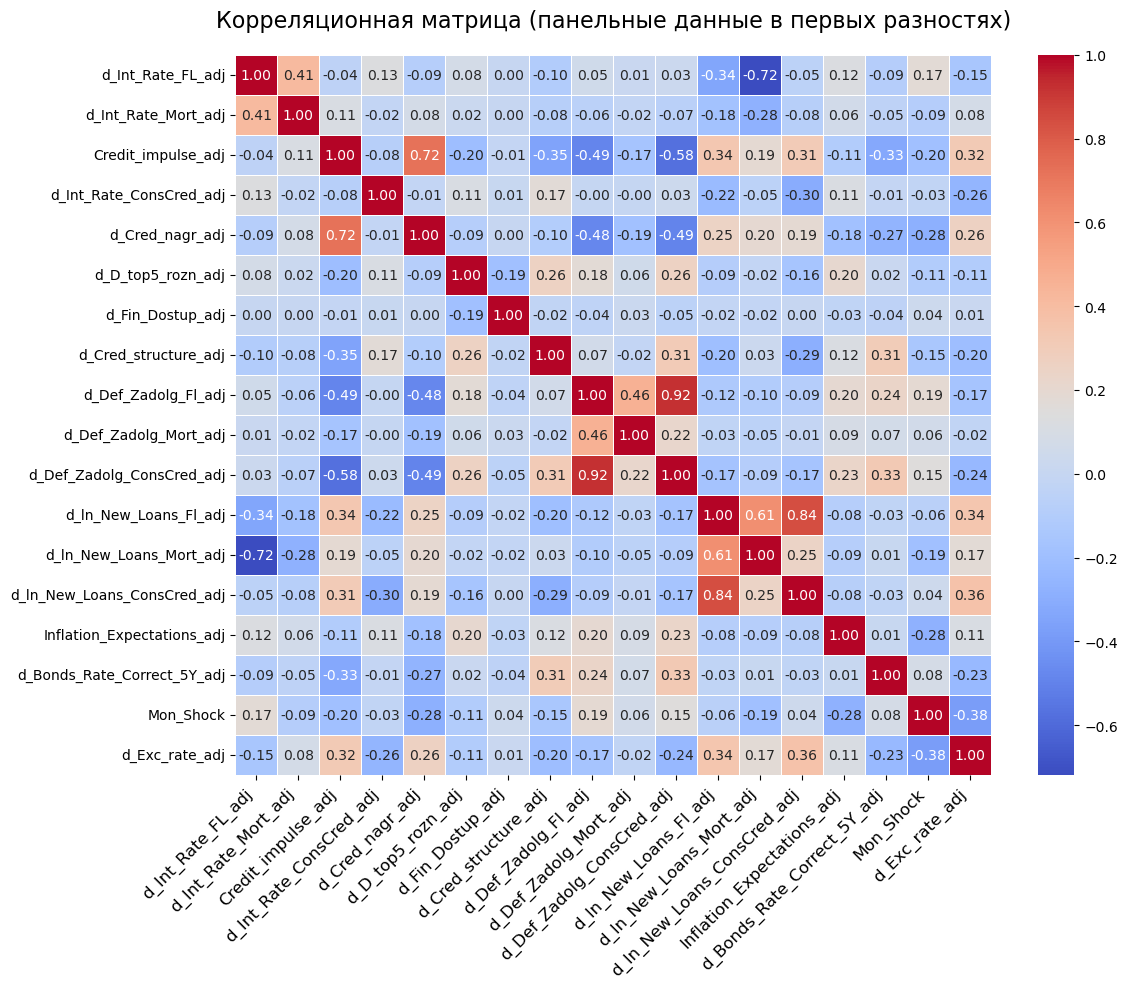

In [265]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [266]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                   
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1
                   Variable      VIF
         Credit_impulse_adj 2.869741
            d_Cred_nagr_adj 2.500568
                  Mon_Shock 1.527396
        d_Def_Zadolg_Fl_adj 1.501506
             d_Exc_rate_adj 1.484644
       d_Cred_structure_adj 1.454145
 Inflation_Expectations_adj 1.308242
d_Bonds_Rate_Correct_5Y_adj 1.289925
      d_ln_New_Loans_Fl_adj 1.269911
          d_D_top5_rozn_adj 1.217646
     d_Int_Rate_FL_lag1_adj 1.107186
           d_Fin_Dostup_adj 1.047496


In [267]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
   # 'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                   
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2
                    Variable      VIF
          Credit_impulse_adj 2.901160
             d_Cred_nagr_adj 2.486340
   d_Def_Zadolg_ConsCred_adj 1.741723
                   Mon_Shock 1.552253
              d_Exc_rate_adj 1.542546
        d_Cred_structure_adj 1.473383
 d_ln_New_Loans_ConsCred_adj 1.346171
  Inflation_Expectations_adj 1.295935
 d_Bonds_Rate_Correct_5Y_adj 1.291990
           d_D_top5_rozn_adj 1.225588
d_Int_Rate_ConsCred_lag1_adj 1.067992
            d_Fin_Dostup_adj 1.046998


In [268]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    #'d_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                     
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3
                   Variable      VIF
         Credit_impulse_adj 2.665395
            d_Cred_nagr_adj 2.466738
                  Mon_Shock 1.485546
       d_Cred_structure_adj 1.441522
             d_Exc_rate_adj 1.365321
 Inflation_Expectations_adj 1.275816
d_Bonds_Rate_Correct_5Y_adj 1.248270
          d_D_top5_rozn_adj 1.203648
    d_ln_New_Loans_Mort_adj 1.107367
      d_Def_Zadolg_Mort_adj 1.053211
           d_Fin_Dostup_adj 1.047360
   d_Int_Rate_Mort_lag1_adj 1.045549


In [271]:
###############################
    #Тест на стационарность I(1) рядов
###############################

custom_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'd_ln_New_Loans_Fl_adj',         
    'd_ln_New_Loans_Mort_adj',       
    'd_ln_New_Loans_ConsCred_adj',   
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj'
]

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests_python(df_exog, panel_vars=custom_vars)
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ")
print("="*70)

Тестирование 21 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_FL_adj
  2. d_Int_Rate_FL_lag1_adj
  3. d_Int_Rate_Mort_adj
  4. Credit_impulse_adj
  5. d_Int_Rate_Mort_lag1_adj
  6. d_Int_Rate_ConsCred_adj
  7. d_Int_Rate_ConsCred_lag1_adj
  8. d_Cred_nagr_adj
  9. d_D_top5_rozn_adj
  10. d_Fin_Dostup_adj
  11. d_Cred_structure_adj
  12. d_Def_Zadolg_Fl_adj
  13. d_Def_Zadolg_Mort_adj
  14. d_Def_Zadolg_ConsCred_adj
  15. d_ln_New_Loans_Fl_adj
  16. d_ln_New_Loans_Mort_adj
  17. d_ln_New_Loans_ConsCred_adj
  18. Inflation_Expectations_adj
  19. d_Bonds_Rate_Correct_5Y_adj
  20. Mon_Shock
  21. d_Exc_rate_adj

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
                  Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
           d_Int_Rate_FL_adj    0.037423         0.449  -0

In [272]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5852 entries, 1 to 6082
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Region                        5852 non-null   object        
 1   Date                          5852 non-null   datetime64[ns]
 2   d_Int_Rate_FL_adj             5852 non-null   float64       
 3   d_Int_Rate_FL_lag1_adj        5852 non-null   float64       
 4   d_Int_Rate_Mort_adj           5852 non-null   float64       
 5   Credit_impulse_adj            5852 non-null   float64       
 6   d_Int_Rate_Mort_lag1_adj      5852 non-null   float64       
 7   d_Int_Rate_ConsCred_adj       5852 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1_adj  5852 non-null   float64       
 9   d_Cred_nagr_adj               5852 non-null   float64       
 10  d_D_top5_rozn_adj             5852 non-null   float64       
 11  d_Fin_Dostup_adj              5852 

In [273]:
###############################
# Построение линейных моделей на панельных данных
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE")
print("Зависимая переменная: d_Int_Rate_FL")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
   # 'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_FL_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE
Зависимая переменная: d_Int_Rate_FL

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:      d_Int_Rate_FL_adj   R-squared:                        0.2057
Estimator:                  PooledOLS   R-squared (Between):              0.7317
No. Observations:                5852   R-squared (Within):               0.2020
Date:                 Чт, дек 11 2025   R-squared (Overall):              0.2057
Time:                        15:44:07   Log-likelihood                   -7768.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      137.52
Entities:                          77   P-value                           0.0000
Avg Obs:                       76.000   Distribution:                 F(11,5841)
Min Obs:                       76.000                                           
Max Obs:       

In [274]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -156.4277
p-значение: 1.000000
df: 11

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 2950.9552
p-значение: 0.000000
N (регионов): 77, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -40.6267
p-значение: 1.000000
df: (76, 5764)

Вывод: p >= 0.05 - Pooled адекватна


In [275]:
###############################
# Построение линейных моделей на панельных данных
# (d_Int_Rate_ConsCred зависимая переменная)
###############################

print("="*60)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ POOL + КЛАСТЕРИЗОВАННЫЕ SE; ЗАВИСИМАЯ ПЕРЕМЕННАЯ d_Int_Rate_ConsCred")
print("="*60)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    #'d_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                          
]

dependent_var = 'd_Int_Rate_ConsCred_adj'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ POOL + КЛАСТЕРИЗОВАННЫЕ SE; ЗАВИСИМАЯ ПЕРЕМЕННАЯ d_Int_Rate_ConsCred

МОДЕЛЬ 1: POOLED OLS
                             PooledOLS Estimation Summary                            
Dep. Variable:     d_Int_Rate_ConsCred_adj   R-squared:                        0.2609
Estimator:                       PooledOLS   R-squared (Between):              0.8595
No. Observations:                     5852   R-squared (Within):               0.2547
Date:                      Чт, дек 11 2025   R-squared (Overall):              0.2609
Time:                             15:44:35   Log-likelihood                -1.094e+04
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      171.77
Entities:                               77   P-value                           0.0000
Avg Obs:                            76.000   Distribution:                 F(12,5840)
Min Obs:                     

In [276]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -117.6433
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 2953.5638
p-значение: 0.000000
N (регионов): 77, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -42.1751
p-значение: 1.000000
df: (76, 5763)

Вывод: p >= 0.05 - Pooled адекватна


In [277]:
###############################
# Построение линейных моделей на панельных данных
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*60)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ POOL + КЛАСТЕРИЗОВАННЫЕ SE; ЗАВИСИМАЯ ПЕРЕМЕННАЯ d_Int_Rate_Mort")
print("="*60)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
   # 'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj'                        
]

dependent_var = 'd_Int_Rate_Mort_adj'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ POOL + КЛАСТЕРИЗОВАННЫЕ SE; ЗАВИСИМАЯ ПЕРЕМЕННАЯ d_Int_Rate_Mort

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_Mort_adj   R-squared:                        0.1976
Estimator:                   PooledOLS   R-squared (Between):              0.6744
No. Observations:                 5852   R-squared (Within):               0.1957
Date:                  Чт, дек 11 2025   R-squared (Overall):              0.1976
Time:                         15:45:45   Log-likelihood                   -5025.8
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      119.83
Entities:                           77   P-value                           0.0000
Avg Obs:                        76.000   Distribution:                 F(12,5840)
Min Obs:                        76.000                                   

In [278]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -7.0801
p-значение: 1.000000
df: 12

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 2955.6330
p-значение: 0.000000
N (регионов): 77, T (периодов): 76

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -12.4074
p-значение: 1.000000
df: (76, 5763)

Вывод: p >= 0.05 - Pooled адекватна


In [279]:
df_clean.head()

d_Int_Rate_FL_adj  d_Int_Rate_FL_lag1_adj  \
Region         Date                                                    
Алтайский край 2019-05-01           0.127487                0.453947   
               2019-06-01          -0.043702                0.169795   
               2019-07-01           0.004456               -0.022364   
               2019-08-01           0.180503                0.019036   
               2019-09-01          -0.230489                0.115561   

                           d_Int_Rate_Mort_adj  Credit_impulse_adj  \
Region         Date                                                  
Алтайский край 2019-05-01             0.212513            2.653092   
               2019-06-01            -0.035967            3.145955   
               2019-07-01             0.073591            1.974579   
               2019-08-01            -0.121469            2.614936   
               2019-09-01            -0.291968            1.828907   

                           d_Int_Rate_Mort_lag1_adj  d_Int_Rate_ConsCred_adj  \
Region         Date                                                            
Алтайский край 2019-05-01                  0.534088                -0.009904   
               2019-06-01                  0.175740                -0.029205   
               2019-07-01                 -0.231480                -0.062038   
               2019-08-01                 -0.121719                 0.220345   
               2019-09-01                 -0.058210                -0.052563   

                           d_Int_Rate_ConsCred_lag1_adj  d_Cred_nagr_adj  \
Region         Date                                                        
Алтайский край 2019-05-01                      0.094145         0.001391   
               2019-06-01                      0.005160         0.000063   
               2019-07-01                     -0.020563         0.001691   
               2019-08-01                     -0.071617         0.001204   
               2019-09-01                      0.227203         0.001501   

                           d_D_top5_rozn_adj  d_Fin_Dostup_adj  ...  \
Region         Date                                             ...   
Алтайский край 2019-05-01          -0.001849          0.148568  ...   
               2019-06-01          -0.001711          0.030936  ...   
               2019-07-01          -0.002279          0.089165  ...   
               2019-08-01          -0.002437          0.110008  ...   
               2019-09-01          -0.000365          0.044396  ...   

                           d_Def_Zadolg_Mort_adj  d_Def_Zadolg_ConsCred_adj  \
Region         Date                                                           
Алтайский край 2019-05-01              -0.007250                  -0.188653   
               2019-06-01              -0.027743                  -0.163713   
               2019-07-01              -0.011765                  -0.188312   
               2019-08-01              -0.011326                  -0.071152   
               2019-09-01              -0.027087                  -0.214003   

                           d_ln_New_Loans_Fl_adj  d_ln_New_Loans_Mort_adj  \
Region         Date                                                         
Алтайский край 2019-05-01               0.076853                 0.087517   
               2019-06-01               0.037104                 0.018172   
               2019-07-01              -0.101967                -0.014579   
               2019-08-01               0.027416                -0.053992   
               2019-09-01              -0.016606                 0.047768   

                           d_ln_New_Loans_ConsCred_adj  \
Region         Date                                      
Алтайский край 2019-05-01                     0.035261   
               2019-06-01                    -0.052758   
               2019-07-01                    -0.078541   
               2019-08-01                     0.056817 

In [298]:
###############################
# Построение PVAR S-GMM моделей
###############################
from pydynpd import regression

# Подготовка данных
df_for_gmm = df_clean.reset_index()
df_for_gmm = df_for_gmm.sort_values(['Region', 'Date'])

# System GMM 

# Используем спецификацию, которая работала ранее
command_str_system = (
    'd_Int_Rate_FL_adj L1.d_Int_Rate_FL_adj '
    'd_Cred_nagr_adj d_D_top5_rozn_adj '
    'Mon_Shock d_Bonds_Rate_Correct_5Y_adj d_Exc_rate_adj | '
    'gmm(d_Int_Rate_FL_adj, 2:4) '
    'iv(d_Cred_nagr_adj d_D_top5_rozn_adj Mon_Shock d_Bonds_Rate_Correct_5Y_adj d_Exc_rate_adj) | '
    'collapse'
)

mydpd_system = regression.abond(command_str_system, df_for_gmm, ['Region', 'Date'])


 Dynamic panel-data estimation, two-step system GMM
 Group variable: Region                           Number of obs = 5698     
 Time variable: Date                              Min obs per group: 74    
 Number of instruments = 10                       Max obs per group: 74    
 Number of groups = 77                            Avg obs per group: 74.00 
+-----------------------------+------------+---------------------+------------+-----------+-----+
|      d_Int_Rate_FL_adj      |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+-----------------------------+------------+---------------------+------------+-----------+-----+
|     L1.d_Int_Rate_FL_adj    | -0.0337699 |      0.0386386      | -0.8739941 | 0.3821215 |     |
|       d_Cred_nagr_adj       | -8.1378129 |      1.7995863      | -4.5220465 | 0.0000061 | *** |
|      d_D_top5_rozn_adj      | 25.6762628 |      14.1707249     | 1.8119230  | 0.0699981 |     |
|          Mon_Shock          | 3.6011689  |      0.2689